# 06 — โครงสร้างพายุในแนวดิ่ง ภาคตัดขวาง และแนวคิด Echo Top
## Vertical Storm Structure, Cross Sections and Echo-Top Concepts

**กรณีศึกษา**

- Radar site: **Omkoi**
- Agency: **Department of Royal Rainmaking and Agricultural Aviation (DRRAA)**
- Radar band: **S-band**
- Event: **observed hail event**
- Date: **18 March 2023**
- Peak representative volume: อ่านจาก Notebook 03
- Native scan strategy: **14 elevation sweeps**
- Strong-echo orientation: อ่านจาก Notebook 02/03
- Cartesian 3-D grids: อ่านจาก Notebook 03
- Figure text: **English only**
- Teaching explanation: **ภาษาไทย**

---

## แนวคิดหลักของบท

Notebook 01–03 ทำให้เราเข้าใจ:

```text
Radar volume
→ PPI
→ beam geometry
→ Cartesian grid
→ CAPPI
```

Notebook 06 จะเปลี่ยนมุมมองจาก **แผนที่แนวนอน** ไปสู่ **โครงสร้างพายุสามมิติ**

```text
PPI volume
      ↓
เลือกแนว azimuth ผ่าน storm core
      ↓
Native pseudo-RHI
      ↓
Cartesian vertical cross section
      ↓
เปรียบเทียบ native sampling กับ interpolated grid
      ↓
Vertical core structure
      ↓
Threshold-top / echo-base concepts
      ↓
เตรียมเข้าสู่ ET / VIL / VILD ใน Notebook 07
```

> **หลักสำคัญ**
>
> `PPI ≠ vertical cross section`
>
> `Pseudo-RHI ≠ true RHI scan`
>
> `Cartesian cross section ≠ original observation`
>
> `Radar echo top ≠ cloud top`
>
> `Radar echo base ≠ thermodynamic cloud base`
>
> `High reflectivity aloft supports severe-storm interpretation, but does not by itself prove hail at the surface`

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 06 ผู้เรียนควรสามารถ:

1. อธิบายความแตกต่างระหว่าง PPI, RHI และ pseudo-RHI
2. อธิบายว่าทำไม PPI volume 14 elevations สามารถใช้สร้าง vertical cross section ได้
3. เลือก azimuth ผ่าน storm core อย่างมีหลักการ
4. ใช้ strong-echo orientation จาก Notebook 02/03 เป็น cross-section reference
5. ตรวจ nearest ray ในแต่ละ sweep
6. สร้าง pseudo-RHI จาก native polar radar volume
7. ใช้ `pyart.util.cross_section_ppi()`
8. แสดง native gate sampling ในพิกัด range–height
9. อ่าน storm-focused 3-D Cartesian grid จาก Notebook 03
10. สร้าง radial Cartesian cross section
11. เปรียบเทียบ native pseudo-RHI กับ Cartesian cross section
12. อธิบายข้อดีและข้อจำกัดของแต่ละ representation
13. ระบุ height of maximum reflectivity
14. วิเคราะห์ vertical extent ของ 30/40/50/55/60-dBZ cores
15. อธิบาย threshold-top concept
16. อธิบาย echo-base concept
17. ตรวจ top-censoring และ bottom-censoring จาก grid boundaries
18. สร้าง vertical reflectivity profile ผ่าน intense core
19. ทำ azimuth-sensitivity experiment
20. อธิบายว่าการเลื่อน cross-section line ไม่กี่องศาสามารถเปลี่ยน storm interpretation ได้
21. ใช้ optional environmental thermal levels หากมี
22. แยก freezing level / mixed-phase levels ออกจาก radar-derived structure
23. export cross-section tables และ processing metadata
24. เตรียมข้อมูลสำหรับ Notebook 07 — ET20/30/40/50, VIL, VILD และ storm-core metrics

**CORE** — ปริญญาตรี  
**ADVANCED** — ปริญญาโท  
**EXPERIMENT** — sensitivity test  
**RESEARCH NOTE** — ประเด็นที่ควรรายงานในงานวิจัย

# 1. ทฤษฎี PPI, RHI และ pseudo-RHI

### PPI — Plan Position Indicator

เรดาร์หมุนรอบ azimuth ที่ elevation angle คงที่

ดังนั้น PPI เป็นพื้นผิวรูปกรวย ไม่ใช่ horizontal plane

### RHI — Range Height Indicator

RHI จริงเกิดจากการสแกน elevation ขึ้นลงตาม azimuth คงที่

### pseudo-RHI

เมื่อเรามี volume scan แบบ PPI หลาย elevation:

```text
0.5°
1.5°
2.4°
...
19.5°
```

เราสามารถเลือก ray ที่ azimuth ใกล้เคียงกันจากทุก sweep แล้วนำมาวางในพิกัด:

```text
horizontal range
vs
height
```

จึงได้ **pseudo-RHI**

ข้อแตกต่างสำคัญ:

```text
True RHI
= radar physically scans vertically along one azimuth

Pseudo-RHI
= reconstruct vertical section from multiple PPI sweeps
```

ดังนั้น pseudo-RHI อาจมี time offset เล็กน้อยระหว่าง elevation sweeps และ azimuth ของ ray แต่ละ sweepอาจไม่ตรงกันแบบสมบูรณ์

# 2. Native polar cross section กับ Cartesian cross section

Notebook นี้สอนสอง representation คู่กัน

## A. Native polar pseudo-RHI

```text
Original radar gates
        ↓
one ray from each PPI sweep
        ↓
range–height representation
```

ข้อดี:

- ใกล้ original observation
- เห็น sampling geometry
- ไม่ผ่าน Cartesian interpolation

ข้อจำกัด:

- ray spacing ในแนวดิ่งไม่สม่ำเสมอ
- azimuth อาจคลาดเล็กน้อยระหว่าง sweeps
- beam broadening เพิ่มตามระยะ

## B. Cartesian cross section

```text
Radar volume
      ↓
3-D Cartesian interpolation
      ↓
sample vertical plane
```

ข้อดี:

- ระยะและความสูงอยู่บน grid สม่ำเสมอ
- คำนวณพื้นที่/ความลึก/threshold tops ได้สะดวก
- เหมาะกับ object-based severe-storm metrics

ข้อจำกัด:

- เป็น interpolated representation
- grid spacing ไม่ใช่ observational resolution
- interpolation สามารถ smooth local maxima ได้

# 3. Echo top และ cloud top ไม่ใช่สิ่งเดียวกัน

Radar echo top นิยามจากระดับสูงสุดที่ radar reflectivity ยังมากกว่า threshold ที่กำหนด เช่น:

$$
ET_{40}
=
\max
\left\{
z:
Z_H(z)\ge40\;dBZ
\right\}
$$

แต่:

```text
Echo top
≠
physical cloud top
```

เพราะ cloud particles บริเวณยอดเมฆอาจเล็กเกินกว่าที่ weather radar จะตรวจได้ชัดเจน

เช่นเดียวกัน:

```text
Radar echo base
≠
thermodynamic cloud base
```

Cloud base ทางอุณหพลศาสตร์ควรพิจารณาจาก:

- LCL
- sounding
- ceilometer
- cloud-base observation

ใน Notebook 06 เราจะใช้คำว่า **radar echo base** เท่านั้น

# 4. Threshold-top concept สำหรับ severe convection

ตัวอย่าง thresholds:

```text
20 dBZ → broader precipitating echo
30 dBZ → moderate echo structure
40 dBZ → strong convective core
50 dBZ → intense convective core
55–60 dBZ → very intense reflectivity
```

แต่ต้องระวัง:

```text
ET50 ≠ hail
60 dBZ ≠ hail confirmation
```

สิ่งที่มีความหมายทางกายภาพมากกว่าคือ:

> strong reflectivity core extending to large altitude

และเมื่อมี environmental temperature profile:

> strong reflectivity extending well above the freezing and mixed-phase levels

จึงจะเชื่อมโยงกับ hail-growth environment ได้มีเหตุผลมากขึ้น

# 5. ติดตั้งไลบรารีสำหรับ Google Colab

In [1]:
# CELL 1 — Install Notebook 06 packages

import sys
import subprocess

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "numpy>=1.26",
    "pandas>=2.0",
    "matplotlib>=3.8",
    "scipy>=1.12",
    "netCDF4>=1.6",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 06 ...")
subprocess.check_call(cmd)
print("พร้อมใช้งาน")

กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 06 ...
พร้อมใช้งาน


# 6. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()

    print(
        "ไม่พบ google.colab — "
        "ใช้โฟลเดอร์ปัจจุบันแทน:"
    )

    print(
        DRIVE_ROOT
    )

Mounted at /content/drive


# 7. นำเข้าไลบรารีและกำหนดมาตรฐาน publication-quality figures

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import gc
import gzip
import json
import math
import shutil
import sys
import tempfile
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

import pyart

from netCDF4 import num2date

from scipy.interpolate import (
    RegularGridInterpolator,
)

from IPython.display import (
    display,
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "pyart": pyart.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=[
            "software",
            "version",
        ],
    )
)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5


In [4]:
# CELL 4 — Plotting standard and figure manifest

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.constrained_layout.use": True,
})

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    **meta,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": path.name,
        "figure_path": str(
            path
        ),
        **meta,
        "dpi": 300,
    })

    print(
        "Saved:",
        path,
    )


def resolve_reflectivity_colormap():
    for candidate in [
        "NWSRef",
        "HomeyerRainbow",
        "Carbone11",
        "turbo",
    ]:
        if candidate in matplotlib.colormaps:
            return candidate

    return "viridis"


ZH_CMAP = (
    resolve_reflectivity_colormap()
)

ZH_VMIN = -10.0
ZH_VMAX = 70.0

print(
    "Reflectivity colormap:",
    ZH_CMAP,
)

Reflectivity colormap: NWSRef


# 8. อ่าน active-event configuration และ readiness

Notebook 06 เป็น severe-weather branch ที่ต่อโดยตรงจาก Notebook 03

ดังนั้น dependency หลักคือ:

```text
Notebook 01
→ Notebook 02
→ Notebook 03
→ Notebook 06
```

Notebook 04–05 เป็นสาย QPE/GIS และไม่ใช่ dependency ทางกายภาพของ vertical-storm analysis

อย่างไรก็ตาม หาก Notebook 05 ถูก run แล้ว Notebook 06 จะรายงานสถานะไว้เพื่อแสดง progression ของหลักสูตร

In [5]:
# CELL 5 — Load course configuration

COURSE_NAME = (
    "Teaching_DRRAA_WeatherRadar_GIS"
)

ROOT = (
    DRIVE_ROOT
    / COURSE_NAME
)

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "ไม่พบ course_config.json — "
        "ให้รัน Notebook 01 ก่อน"
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(
        stream
    )

WORKSPACE = COURSE_CONFIG[
    "workspace"
]

ACTIVE_EVENT = COURSE_CONFIG.get(
    "active_event",
    {},
)

if ACTIVE_EVENT.get(
    "event_type"
) != "observed_hail":
    raise RuntimeError(
        "Active event ไม่ใช่ observed_hail"
    )

print(
    "Active event:",
    ACTIVE_EVENT.get(
        "event_id"
    ),
)

print(
    ACTIVE_EVENT.get(
        "event_label"
    )
)

Active event: 20230318_observed_hail_1106_1200
Omkoi observed hail event, 18 March 2023


In [6]:
# CELL 6 — Event-specific paths

RADAR_DIR = Path(
    WORKSPACE[
        "radar"
    ]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE[
        "output_csv"
    ]
)

EVENT_ROOT = Path(
    WORKSPACE[
        "event_root"
    ]
)

OUTPUT_NETCDF_DIR = (
    EVENT_ROOT
    / "03_output"
    / "netcdf"
)

FIGURE_DIR = (
    Path(
        WORKSPACE[
            "figures"
        ]
    ).parent
    / "06"
)

for folder in [
    OUTPUT_CSV_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


READINESS_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_readiness_check.csv"
)

GRID_CONFIG_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_configuration.csv"
)

STORM_ROI_02_CSV = (
    OUTPUT_CSV_DIR
    / "02_storm_focus_ROI.csv"
)

READINESS_05_CSV = (
    OUTPUT_CSV_DIR
    / "05_readiness_check.csv"
)

for required_file in [
    READINESS_03_CSV,
    GRID_CONFIG_03_CSV,
    STORM_ROI_02_CSV,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"ไม่พบไฟล์ที่ต้องใช้: {required_file}"
        )


readiness_03 = pd.read_csv(
    READINESS_03_CSV
)

if not (
    readiness_03[
        "status"
    ]
    == "PASS"
).all():
    display(
        readiness_03
    )

    raise RuntimeError(
        "Notebook 03 readiness ยังไม่ผ่าน"
    )


grid_config_03 = pd.read_csv(
    GRID_CONFIG_03_CSV
)

grid_config_lookup = dict(
    zip(
        grid_config_03[
            "parameter"
        ],
        grid_config_03[
            "value"
        ],
    )
)


storm_roi_02 = pd.read_csv(
    STORM_ROI_02_CSV
)

storm_roi_lookup = dict(
    zip(
        storm_roi_02[
            "parameter"
        ],
        storm_roi_02[
            "value"
        ],
    )
)


if READINESS_05_CSV.exists():
    readiness_05 = pd.read_csv(
        READINESS_05_CSV
    )

    NOTEBOOK_05_STATUS = bool(
        (
            readiness_05[
                "status"
            ]
            == "PASS"
        ).all()
    )

else:
    readiness_05 = None
    NOTEBOOK_05_STATUS = None


print(
    "Notebook 03 readiness: PASS"
)

print(
    "Notebook 05 status:",
    (
        "PASS"
        if NOTEBOOK_05_STATUS is True
        else "not required / not available"
    ),
)

Notebook 03 readiness: PASS
Notebook 05 status: PASS


# 9. Parameter block

ค่าหลักของ cross section จะอ่านจาก strong-echo orientation ที่ Notebook 02/03 วิเคราะห์ไว้แล้ว

สำหรับ event นี้คาดว่าอยู่ประมาณ:

```text
ENE
azimuth ≈ 74°
range ≈ 97 km
```

Notebook ไม่ hard-code ค่าดังกล่าว แต่ดึงจาก metadata

### Cross-section sensitivity

จะสร้าง 3 แนว:

```text
target azimuth − 4°
target azimuth
target azimuth + 4°
```

เพื่อให้นิสิตเห็นว่าการเลือกแนวตัดมีผลต่อ vertical structure อย่างไร

In [7]:
# CELL 7 — Scientific parameters

FIELD_Z = str(
    grid_config_lookup[
        "field"
    ]
)

SELECTED_FILENAME = str(
    grid_config_lookup[
        "source_file"
    ]
)

TARGET_AZIMUTH_DEG = float(
    grid_config_lookup[
        "strong_echo_reference_azimuth_deg"
    ]
)

CORE_REFERENCE_RANGE_KM = float(
    grid_config_lookup[
        "strong_echo_reference_range_km"
    ]
)

DOMINANT_SECTOR = str(
    grid_config_lookup[
        "strong_echo_sector"
    ]
)

AZIMUTH_TOLERANCE_DEG = 1.0

AZIMUTH_OFFSETS_DEG = [
    -4.0,
    0.0,
    4.0,
]

AZIMUTH_EXPERIMENT_DEG = [
    (
        TARGET_AZIMUTH_DEG
        + offset
    )
    % 360.0
    for offset in (
        AZIMUTH_OFFSETS_DEG
    )
]

SECTION_SPACING_KM = 0.5

SECTION_MAX_RANGE_KM = 220.0

VERTICAL_DISPLAY_MIN_KM_MSL = 1.0

VERTICAL_DISPLAY_MAX_KM_MSL = 20.0

REFLECTIVITY_CONTOURS_DBZ = [
    30.0,
    40.0,
    50.0,
    55.0,
    60.0,
]

THRESHOLD_TOPS_DBZ = [
    20.0,
    30.0,
    40.0,
    50.0,
]

ECHO_BASE_THRESHOLD_DBZ = 20.0

print(
    "Target azimuth:",
    f"{TARGET_AZIMUTH_DEG:.2f}°",
)

print(
    "Core reference range:",
    f"{CORE_REFERENCE_RANGE_KM:.2f} km",
)

print(
    "Dominant sector:",
    DOMINANT_SECTOR,
)

print(
    "Azimuth sensitivity:",
    [
        round(
            value,
            2,
        )
        for value in (
            AZIMUTH_EXPERIMENT_DEG
        )
    ],
)

Target azimuth: 74.37°
Core reference range: 96.77 km
Dominant sector: ENE
Azimuth sensitivity: [70.37, 74.37, 78.37]


# 10. อ่าน peak UF volume และ 3-D grids จาก Notebook 03

Notebook 06 ใช้ข้อมูลสาม representation ของ **เวลาเดียวกัน**:

```text
Native UF radar volume
Full-domain 1-km 3-D grid
Storm-focused 0.5-km 3-D grid
```

การใช้เวลาเดียวกันสำคัญมาก เพราะเราต้องการเปรียบเทียบผลของ representation ไม่ใช่เปรียบเทียบ storm evolution คนละเวลา

In [8]:
# CELL 8 — Robust UF reader

RADAR_CACHE = (
    Path(
        tempfile.gettempdir()
    )
    / "drraa_radar_uf_cache"
)

RADAR_CACHE.mkdir(
    parents=True,
    exist_ok=True,
)


def read_radar_file(
    path,
):
    path = Path(
        path
    )

    try:
        return pyart.io.read(
            str(
                path
            )
        )

    except Exception as direct_error:

        if path.suffix.lower() != ".gz":
            raise

        unpacked = (
            RADAR_CACHE
            / path.with_suffix(
                ""
            ).name
        )

        if not unpacked.exists():

            with gzip.open(
                path,
                "rb",
            ) as source, unpacked.open(
                "wb"
            ) as target:

                shutil.copyfileobj(
                    source,
                    target,
                )

        try:
            return pyart.io.read(
                str(
                    unpacked
                )
            )

        except Exception as unpacked_error:

            raise RuntimeError(
                f"อ่านไฟล์ {path.name} ไม่สำเร็จ "
                f"(compressed={direct_error!r}; "
                f"unpacked={unpacked_error!r})"
            ) from unpacked_error

In [9]:
# CELL 9 — UTC time helper

def radar_datetime_utc(
    radar_object,
):
    units = radar_object.time.get(
        "units"
    )

    if units is None:
        return pd.NaT

    units_text = str(
        units
    ).upper()

    if not (
        "Z" in units_text
        or "UTC" in units_text
        or "+00:00" in units_text
    ):
        raise ValueError(
            "Radar time units ไม่ได้ระบุ UTC อย่างชัดเจน"
        )

    dt = num2date(
        radar_object.time[
            "data"
        ][0],
        units=units,
        calendar=radar_object.time.get(
            "calendar",
            "standard",
        ),
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True,
    )

    timestamp = pd.Timestamp(
        dt
    )

    if timestamp.tzinfo is None:
        timestamp = timestamp.tz_localize(
            "UTC"
        )

    else:
        timestamp = timestamp.tz_convert(
            "UTC"
        )

    return timestamp

In [10]:
# CELL 10 — Read peak radar volume

RADAR_PATH = (
    RADAR_DIR
    / SELECTED_FILENAME
)

if not RADAR_PATH.exists():
    raise FileNotFoundError(
        f"ไม่พบ peak radar file: {RADAR_PATH}"
    )

radar = read_radar_file(
    RADAR_PATH
)

if FIELD_Z not in radar.fields:
    raise KeyError(
        f"ไม่พบ field {FIELD_Z} ใน radar volume"
    )

utc_time = radar_datetime_utc(
    radar
)

radar_lat = float(
    radar.latitude[
        "data"
    ][0]
)

radar_lon = float(
    radar.longitude[
        "data"
    ][0]
)

radar_alt_m_MSL = float(
    radar.altitude[
        "data"
    ][0]
)

print(
    "Radar file:",
    SELECTED_FILENAME,
)

print(
    "UTC:",
    utc_time,
)

print(
    "Sweeps:",
    radar.nsweeps,
)

print(
    "Radar altitude:",
    radar_alt_m_MSL,
    "m MSL",
)

Radar file: 20230318111202.uf.gz
UTC: 2023-03-18 11:12:02+00:00
Sweeps: 14
Radar altitude: 1173.0 m MSL


In [11]:
# CELL 11 — Locate and read Notebook 03 Grid NetCDF files

configured_full_grid = Path(
    str(
        grid_config_lookup[
            "full_grid_NetCDF"
        ]
    )
)

configured_storm_grid = Path(
    str(
        grid_config_lookup[
            "storm_grid_NetCDF"
        ]
    )
)

if configured_full_grid.exists():
    FULL_GRID_NETCDF = (
        configured_full_grid
    )

else:
    candidates = sorted(
        OUTPUT_NETCDF_DIR.glob(
            "03_peak_full_domain_3D_ZH_*UTC.nc"
        )
    )

    if not candidates:
        raise FileNotFoundError(
            "ไม่พบ full-domain 3-D Grid NetCDF"
        )

    FULL_GRID_NETCDF = (
        candidates[
            -1
        ]
    )


if configured_storm_grid.exists():
    STORM_GRID_NETCDF = (
        configured_storm_grid
    )

else:
    candidates = sorted(
        OUTPUT_NETCDF_DIR.glob(
            "03_peak_storm_focus_3D_ZH_*UTC.nc"
        )
    )

    if not candidates:
        raise FileNotFoundError(
            "ไม่พบ storm-focused 3-D Grid NetCDF"
        )

    STORM_GRID_NETCDF = (
        candidates[
            -1
        ]
    )


full_grid = pyart.io.read_grid(
    str(
        FULL_GRID_NETCDF
    )
)

storm_grid = pyart.io.read_grid(
    str(
        STORM_GRID_NETCDF
    )
)

print(
    "Full-grid shape:",
    full_grid.fields[
        FIELD_Z
    ][
        "data"
    ].shape,
)

print(
    "Storm-grid shape:",
    storm_grid.fields[
        FIELD_Z
    ][
        "data"
    ].shape,
)

Full-grid shape: (38, 441, 441)
Storm-grid shape: (38, 329, 422)


# 11. Optional environmental thermal levels

การตีความ hail growth จะดีขึ้นมากเมื่อรู้ระดับ:

```text
0°C
−10°C
−20°C
−30°C
```

แต่ radar เพียงอย่างเดียวไม่สามารถให้ temperature profile ได้โดยตรง

Notebook จึง **ไม่ hard-code thermal levels**

หากมีไฟล์:

```text
environment_thermal_levels_20230318.csv
```

และมี columns เช่น:

```text
freezing_level_m
minus10C_level_m
minus20C_level_m
minus30C_level_m
```

Notebook จะ overlay ระดับเหล่านี้บน vertical cross section

หากไม่มีไฟล์ ส่วนนี้จะ skip โดยไม่ทำให้ Notebook ล้ม

In [12]:
# CELL 12 — Optional thermal-level loader

THERMAL_LEVEL_CANDIDATES = [
    EVENT_ROOT
    / "02_metadata"
    / "environment_thermal_levels_20230318.csv",
    EVENT_ROOT
    / "environment_thermal_levels_20230318.csv",
    ROOT
    / "environment_thermal_levels_20230318.csv",
]

THERMAL_LEVELS = {}

THERMAL_LEVEL_SOURCE = None

for candidate in (
    THERMAL_LEVEL_CANDIDATES
):
    if not candidate.exists():
        continue

    thermal_df = pd.read_csv(
        candidate
    )

    if thermal_df.empty:
        continue

    row = thermal_df.iloc[
        0
    ]

    column_map = {
        "0°C": "freezing_level_m",
        "−10°C": "minus10C_level_m",
        "−20°C": "minus20C_level_m",
        "−30°C": "minus30C_level_m",
    }

    for label, column in (
        column_map.items()
    ):
        if (
            column in thermal_df.columns
            and pd.notna(
                row[
                    column
                ]
            )
        ):
            THERMAL_LEVELS[
                label
            ] = float(
                row[
                    column
                ]
            ) / 1000.0

    THERMAL_LEVEL_SOURCE = (
        candidate
    )

    break


THERMAL_LEVELS_AVAILABLE = bool(
    THERMAL_LEVELS
)

print(
    "Thermal levels available:",
    THERMAL_LEVELS_AVAILABLE,
)

if THERMAL_LEVELS_AVAILABLE:
    print(
        THERMAL_LEVELS
    )

    print(
        "Source:",
        THERMAL_LEVEL_SOURCE,
    )

else:
    print(
        "No thermal-level file found — "
        "thermal overlays will be skipped."
    )

Thermal levels available: False
No thermal-level file found — thermal overlays will be skipped.


# 12. ตรวจ scan strategy ก่อนวิเคราะห์โครงสร้างแนวดิ่ง

Vertical interpretation มีคุณภาพได้เพียงเท่าที่ native elevation sampling รองรับ

Event นี้มี 14 sweeps ซึ่งเหมาะกับการสอน vertical storm structure มากกว่ากรณีที่มีเพียง 3–4 elevation angles

Notebook จะตรวจ:

- fixed angle
- number of rays
- nearest ray to target azimuth
- azimuth mismatch
- beam-center height ที่ core reference range

In [13]:
# CELL 13 — Circular angular difference helper

def angular_difference_deg(
    angle,
    target,
):
    return np.abs(
        (
            (
                np.asarray(
                    angle,
                    dtype=float,
                )
                - float(
                    target
                )
                + 180.0
            )
            % 360.0
        )
        - 180.0
    )

In [14]:
# CELL 14 — Sweep sampling summary at target azimuth

sweep_rows = []

for sweep in range(
    radar.nsweeps
):
    start_ray = int(
        radar.sweep_start_ray_index[
            "data"
        ][
            sweep
        ]
    )

    end_ray = int(
        radar.sweep_end_ray_index[
            "data"
        ][
            sweep
        ]
    )

    sweep_azimuths = np.asarray(
        radar.azimuth[
            "data"
        ][
            start_ray:
            end_ray
            + 1
        ],
        dtype=float,
    )

    differences = angular_difference_deg(
        sweep_azimuths,
        TARGET_AZIMUTH_DEG,
    )

    local_ray = int(
        np.nanargmin(
            differences
        )
    )

    global_ray = (
        start_ray
        + local_ray
    )

    selected_azimuth = float(
        radar.azimuth[
            "data"
        ][
            global_ray
        ]
    )

    gate_x = np.asarray(
        radar.gate_x[
            "data"
        ][
            global_ray
        ],
        dtype=float,
    )

    gate_y = np.asarray(
        radar.gate_y[
            "data"
        ][
            global_ray
        ],
        dtype=float,
    )

    gate_z = np.asarray(
        radar.gate_z[
            "data"
        ][
            global_ray
        ],
        dtype=float,
    )

    horizontal_range_km = (
        np.sqrt(
            gate_x**2
            + gate_y**2
        )
        / 1000.0
    )

    core_gate_index = int(
        np.nanargmin(
            np.abs(
                horizontal_range_km
                - CORE_REFERENCE_RANGE_KM
            )
        )
    )

    core_beam_height_km_MSL = (
        radar_alt_m_MSL
        + gate_z[
            core_gate_index
        ]
    ) / 1000.0

    sweep_rows.append({
        "sweep": (
            sweep
        ),
        "fixed_angle_deg": float(
            radar.fixed_angle[
                "data"
            ][
                sweep
            ]
        ),
        "start_ray": (
            start_ray
        ),
        "end_ray": (
            end_ray
        ),
        "n_rays": (
            end_ray
            - start_ray
            + 1
        ),
        "selected_global_ray": (
            global_ray
        ),
        "selected_azimuth_deg": (
            selected_azimuth
        ),
        "azimuth_error_deg": float(
            angular_difference_deg(
                selected_azimuth,
                TARGET_AZIMUTH_DEG,
            )
        ),
        "beam_center_height_at_core_range_km_MSL": float(
            core_beam_height_km_MSL
        ),
    })


SWEEP_SAMPLING = pd.DataFrame(
    sweep_rows
)

display(
    SWEEP_SAMPLING
)

SWEEP_SAMPLING_CSV = (
    OUTPUT_CSV_DIR
    / "06_native_sweep_cross_section_sampling.csv"
)

SWEEP_SAMPLING.to_csv(
    SWEEP_SAMPLING_CSV,
    index=False,
)

,sweep,fixed_angle_deg,start_ray,end_ray,n_rays,selected_global_ray,selected_azimuth_deg,azimuth_error_deg,beam_center_height_at_core_range_km_MSL
0,0,0.500000,0,338,339,10,74.015625,0.358849,2.568
1,1,1.500000,339,677,339,667,74.312500,0.061974,4.255
2,2,2.406250,678,1016,339,985,74.312500,0.061974,5.784
3,3,3.296875,1017,1355,339,1303,74.890625,0.516151,7.286
4,4,4.203125,1356,1694,339,1620,74.250000,0.124474,8.853
5,5,5.203125,1695,2033,339,1937,74.859375,0.484901,10.543
6,6,6.203125,2034,2372,339,2253,74.046875,0.327599,12.230
7,7,7.500000,2373,2711,339,2569,74.781250,0.406776,14.484
8,8,8.703125,2712,3050,339,2883,74.265625,0.108849,16.593
9,9,10.000000,3051,3389,339,3197,74.187500,0.186974,18.783


# 13. Beam-center geometry ที่ storm reference range

ตารางด้านบนช่วยตอบว่าแต่ละ elevation sweep sample ความสูงใดบริเวณ storm core

นี่เป็นจุดสำคัญในการอ่าน pseudo-RHI:

```text
ความสูงที่ไม่มี native beam ใกล้เคียง
ไม่ควรถูกตีความเหมือน direct observation
```

และยังช่วยอธิบายว่าทำไม Cartesian interpolation จึงมีทั้งประโยชน์และข้อจำกัด

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig01_beam_sampling_at_core_range.png


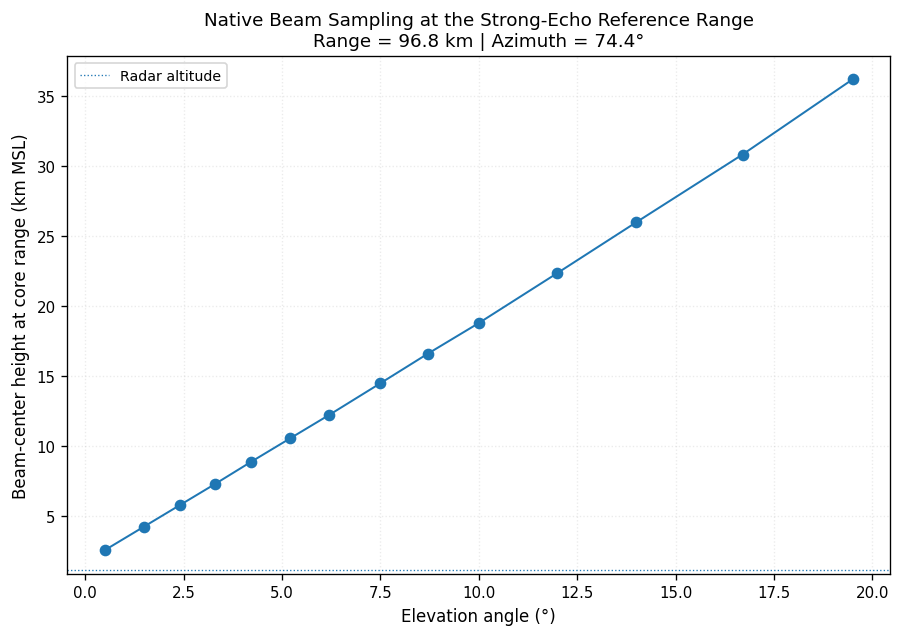

In [15]:
# CELL 15 — Beam-center sampling figure

fig = plt.figure(
    figsize=(
        7.4,
        5.2,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    SWEEP_SAMPLING[
        "fixed_angle_deg"
    ],
    SWEEP_SAMPLING[
        "beam_center_height_at_core_range_km_MSL"
    ],
    marker="o",
)

ax.axhline(
    radar_alt_m_MSL
    / 1000.0,
    linestyle=":",
    linewidth=0.8,
    label="Radar altitude",
)

for label, height_km in (
    THERMAL_LEVELS.items()
):
    ax.axhline(
        height_km,
        linestyle="--",
        linewidth=0.8,
        alpha=0.75,
        label=label,
    )

ax.set_xlabel(
    "Elevation angle (°)"
)

ax.set_ylabel(
    "Beam-center height at core range (km MSL)"
)

ax.set_title(
    (
        "Native Beam Sampling at the Strong-Echo Reference Range\n"
        f"Range = {CORE_REFERENCE_RANGE_KM:.1f} km | "
        f"Azimuth = {TARGET_AZIMUTH_DEG:.1f}°"
    )
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
    ncol=2,
)

F = (
    FIGURE_DIR
    / "06_fig01_beam_sampling_at_core_range.png"
)

save_figure(
    fig,
    F,
    product="beam sampling at core range",
    source_file=(
        SELECTED_FILENAME
    ),
    target_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    core_reference_range_km=(
        CORE_REFERENCE_RANGE_KM
    ),
    units="km MSL",
)

plt.show()

# 14. Reference PPI พร้อมแนว cross section

ก่อนดูภาพแนวดิ่งต้องเห็นว่าแนวตัดผ่านส่วนใดของ storm

Figure นี้จะแสดง:

- lowest-sweep corrected reflectivity
- target azimuth
- strong-echo reference point
- 50 / 100 / 150 / 200 km range rings

แนวตัดเดียวกันจะถูกใช้ใน pseudo-RHI และ Cartesian cross section

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig02_reference_PPI_cross_section_line.png


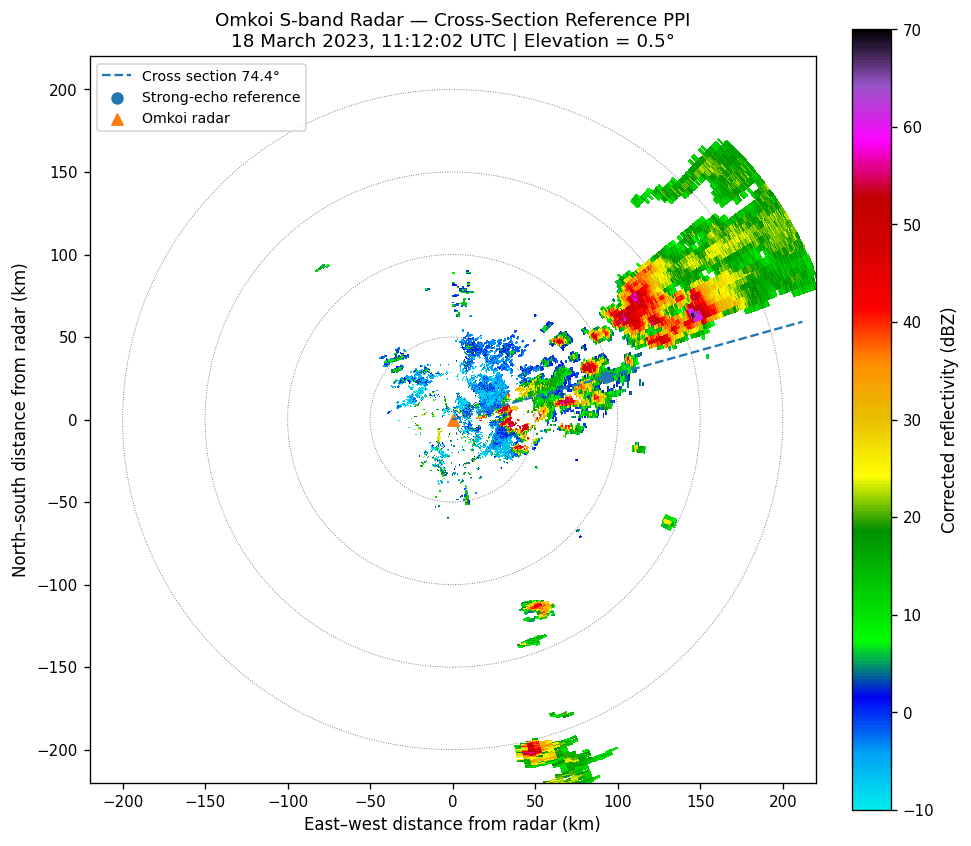

In [16]:
# CELL 16 — Reference PPI with cross-section line

display_radar = pyart.graph.RadarDisplay(
    radar
)

fig = plt.figure(
    figsize=(
        8.0,
        7.1,
    )
)

ax = fig.add_subplot(
    111
)

display_radar.plot_ppi(
    FIELD_Z,
    sweep=0,
    ax=ax,
    fig=fig,
    cmap=(
        ZH_CMAP
    ),
    vmin=(
        ZH_VMIN
    ),
    vmax=(
        ZH_VMAX
    ),
    title=(
        "Omkoi S-band Radar — Cross-Section Reference PPI\n"
        f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')} | "
        f"Elevation = {radar.fixed_angle['data'][0]:.1f}°"
    ),
    colorbar_label=(
        "Corrected reflectivity (dBZ)"
    ),
    raster=True,
)

theta = np.deg2rad(
    TARGET_AZIMUTH_DEG
)

line_range_km = np.array(
    [
        0.0,
        SECTION_MAX_RANGE_KM,
    ]
)

line_x_km = (
    line_range_km
    * np.sin(
        theta
    )
)

line_y_km = (
    line_range_km
    * np.cos(
        theta
    )
)

ax.plot(
    line_x_km,
    line_y_km,
    linestyle="--",
    linewidth=1.4,
    label=(
        f"Cross section {TARGET_AZIMUTH_DEG:.1f}°"
    ),
)

core_x_km = (
    CORE_REFERENCE_RANGE_KM
    * np.sin(
        theta
    )
)

core_y_km = (
    CORE_REFERENCE_RANGE_KM
    * np.cos(
        theta
    )
)

ax.scatter(
    core_x_km,
    core_y_km,
    marker="o",
    s=42,
    label="Strong-echo reference",
)

for radius_km in [
    50,
    100,
    150,
    200,
]:
    ring = plt.Circle(
        (
            0.0,
            0.0,
        ),
        radius_km,
        fill=False,
        linestyle=":",
        linewidth=0.55,
        alpha=0.55,
    )

    ax.add_patch(
        ring
    )

ax.scatter(
    0.0,
    0.0,
    marker="^",
    s=45,
    label="Omkoi radar",
)

ax.set_xlim(
    -220,
    220,
)

ax.set_ylim(
    -220,
    220,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.legend(
    loc="upper left",
    frameon=True,
)

F = (
    FIGURE_DIR
    / "06_fig02_reference_PPI_cross_section_line.png"
)

save_figure(
    fig,
    F,
    product="PPI cross-section reference",
    source_file=(
        SELECTED_FILENAME
    ),
    sweep=0,
    target_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    field=(
        FIELD_Z
    ),
    units="dBZ",
)

plt.show()

# 15. สร้าง pseudo-RHI ด้วย Py-ART

Py-ART มี utility:

```python
pyart.util.cross_section_ppi()
```

ซึ่งเลือก ray ใกล้ target azimuth จากแต่ละ PPI sweep แล้วสร้าง Radar object ที่มีลักษณะ RHI

Notebook จะกำหนด `az_tol=1°`

หาก sweep ใดไม่มี ray ภายใน tolerance การสร้าง cross section อาจไม่ครบ และต้องตรวจ metadata ไม่ใช่เชื่อ figure เพียงอย่างเดียว

In [17]:
# CELL 17 — Create Py-ART pseudo-RHI object

pseudo_rhi = pyart.util.cross_section_ppi(
    radar,
    [
        TARGET_AZIMUTH_DEG
    ],
    az_tol=(
        AZIMUTH_TOLERANCE_DEG
    ),
)

print(
    "Pseudo-RHI scan type:",
    pseudo_rhi.scan_type,
)

print(
    "Pseudo-RHI sweeps:",
    pseudo_rhi.nsweeps,
)

print(
    "Pseudo-RHI rays:",
    pseudo_rhi.nrays,
)

print(
    "Pseudo-RHI gates:",
    pseudo_rhi.ngates,
)

Pseudo-RHI scan type: rhi
Pseudo-RHI sweeps: 1
Pseudo-RHI rays: 14
Pseudo-RHI gates: 475


# 16. Native pseudo-RHI figure

Py-ART pseudo-RHI แสดงแกนแนวดิ่งเป็น **height above radar (ARL)** เป็นหลัก

Pseudo-RHI แสดง reflectivity ในพิกัด:

```text
horizontal range from radar
vs
height
```

Figure นี้ยังอยู่ใกล้ native polar observations มากกว่า Cartesian section

ข้อควรระวัง:

- แต่ละ elevation sweep ถูกวัดคนละเวลาเล็กน้อย
- beam width ไม่ได้แสดงเป็นเส้นบางอย่างแท้จริง
- apparent continuity ระหว่าง sweeps เป็นผลของ plotting representation

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig03_native_pseudo_RHI.png


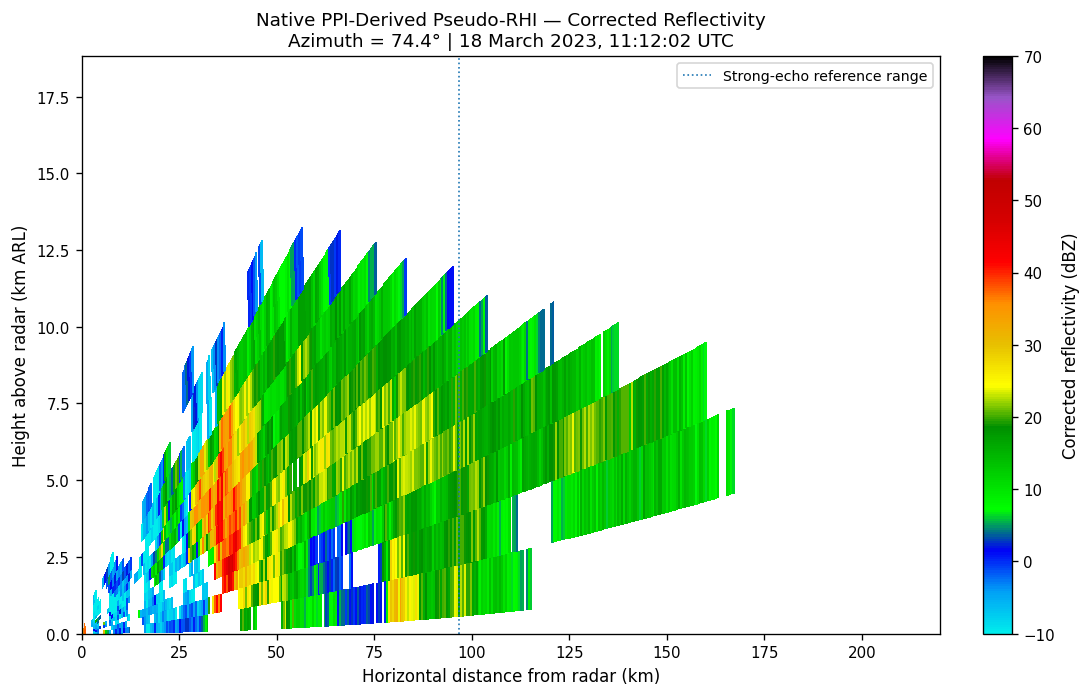

In [18]:
# CELL 18 — Professional Py-ART pseudo-RHI plot

pseudo_display = pyart.graph.RadarDisplay(
    pseudo_rhi
)

fig = plt.figure(
    figsize=(
        9.0,
        5.7,
    )
)

ax = fig.add_subplot(
    111
)

pseudo_display.plot(
    FIELD_Z,
    sweep=0,
    ax=ax,
    fig=fig,
    cmap=(
        ZH_CMAP
    ),
    vmin=(
        ZH_VMIN
    ),
    vmax=(
        ZH_VMAX
    ),
    title=(
        "Native PPI-Derived Pseudo-RHI — Corrected Reflectivity\n"
        f"Azimuth = {TARGET_AZIMUTH_DEG:.1f}° | "
        f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')}"
    ),
    colorbar_label=(
        "Corrected reflectivity (dBZ)"
    ),
    raster=True,
)

ax.set_xlim(
    0.0,
    SECTION_MAX_RANGE_KM,
)

radar_alt_km_MSL = (
    radar_alt_m_MSL
    / 1000.0
)

pseudo_rhi_max_km_ARL = max(
    1.0,
    VERTICAL_DISPLAY_MAX_KM_MSL
    - radar_alt_km_MSL,
)

ax.set_ylim(
    0.0,
    pseudo_rhi_max_km_ARL,
)

ax.axvline(
    CORE_REFERENCE_RANGE_KM,
    linestyle=":",
    linewidth=1.0,
    label="Strong-echo reference range",
)

for label, height_km_MSL in (
    THERMAL_LEVELS.items()
):
    height_km_ARL = (
        height_km_MSL
        - radar_alt_km_MSL
    )

    if height_km_ARL > 0.0:
        ax.axhline(
            height_km_ARL,
            linestyle="--",
            linewidth=0.9,
            alpha=0.80,
            label=(
                f"{label} level"
            ),
        )

ax.set_xlabel(
    "Horizontal distance from radar (km)"
)

ax.set_ylabel(
    "Height above radar (km ARL)"
)

ax.legend(
    loc="upper right",
    frameon=True,
    ncol=2,
)

F = (
    FIGURE_DIR
    / "06_fig03_native_pseudo_RHI.png"
)

save_figure(
    fig,
    F,
    product="native pseudo-RHI",
    source_file=(
        SELECTED_FILENAME
    ),
    target_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    field=(
        FIELD_Z
    ),
    processing=(
        "Py-ART cross_section_ppi using az_tol=1 degree."
    ),
    units="dBZ",
)

plt.show()

# 17. ตรวจ native gates ที่ถูกใช้จริง

เพื่อไม่ให้ pseudo-RHI เป็นเพียงภาพ เราจะสร้างตารางของ ray ที่เลือกในแต่ละ sweep และ gate ทุกจุด

ข้อมูลแต่ละ record มี:

- sweep
- fixed angle
- selected azimuth
- azimuth error
- horizontal range
- height MSL
- corrected reflectivity

ตารางนี้ใช้ต่อเพื่อเปรียบเทียบกับ Cartesian cross section

In [19]:
# CELL 19 — Build native pseudo-RHI gate table

native_gate_rows = []

for _, sweep_row in (
    SWEEP_SAMPLING.iterrows()
):
    sweep = int(
        sweep_row[
            "sweep"
        ]
    )

    global_ray = int(
        sweep_row[
            "selected_global_ray"
        ]
    )

    gate_x = np.asarray(
        radar.gate_x[
            "data"
        ][
            global_ray
        ],
        dtype=float,
    )

    gate_y = np.asarray(
        radar.gate_y[
            "data"
        ][
            global_ray
        ],
        dtype=float,
    )

    gate_z = np.asarray(
        radar.gate_z[
            "data"
        ][
            global_ray
        ],
        dtype=float,
    )

    horizontal_range_km = (
        np.sqrt(
            gate_x**2
            + gate_y**2
        )
        / 1000.0
    )

    height_km_MSL = (
        radar_alt_m_MSL
        + gate_z
    ) / 1000.0

    zh_ray = np.ma.asarray(
        radar.fields[
            FIELD_Z
        ][
            "data"
        ][
            global_ray
        ]
    )

    zh_values = zh_ray.filled(
        np.nan
    )

    for gate_index in range(
        radar.ngates
    ):
        native_gate_rows.append({
            "sweep": (
                sweep
            ),
            "fixed_angle_deg": float(
                sweep_row[
                    "fixed_angle_deg"
                ]
            ),
            "selected_azimuth_deg": float(
                sweep_row[
                    "selected_azimuth_deg"
                ]
            ),
            "azimuth_error_deg": float(
                sweep_row[
                    "azimuth_error_deg"
                ]
            ),
            "gate_index": (
                gate_index
            ),
            "horizontal_range_km": float(
                horizontal_range_km[
                    gate_index
                ]
            ),
            "height_km_MSL": float(
                height_km_MSL[
                    gate_index
                ]
            ),
            "corrected_ZH_dBZ": (
                float(
                    zh_values[
                        gate_index
                    ]
                )
                if np.isfinite(
                    zh_values[
                        gate_index
                    ]
                )
                else np.nan
            ),
        })


NATIVE_PSEUDO_RHI_TABLE = pd.DataFrame(
    native_gate_rows
)

display(
    NATIVE_PSEUDO_RHI_TABLE.head()
)

NATIVE_PSEUDO_RHI_CSV = (
    OUTPUT_CSV_DIR
    / "06_native_pseudo_RHI_gate_table.csv"
)

NATIVE_PSEUDO_RHI_TABLE.to_csv(
    NATIVE_PSEUDO_RHI_CSV,
    index=False,
)

,sweep,fixed_angle_deg,selected_azimuth_deg,azimuth_error_deg,gate_index,horizontal_range_km,height_km_MSL,corrected_ZH_dBZ
0,0,0.5,74.015625,0.358849,0,0.249990,1.175,34.5
1,0,0.5,74.015625,0.358849,1,0.749971,1.179,37.0
2,0,0.5,74.015625,0.358849,2,1.249951,1.183,NaN
3,0,0.5,74.015625,0.358849,3,1.749930,1.188,NaN
4,0,0.5,74.015625,0.358849,4,2.249909,1.193,NaN


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig04_native_gate_sampling.png


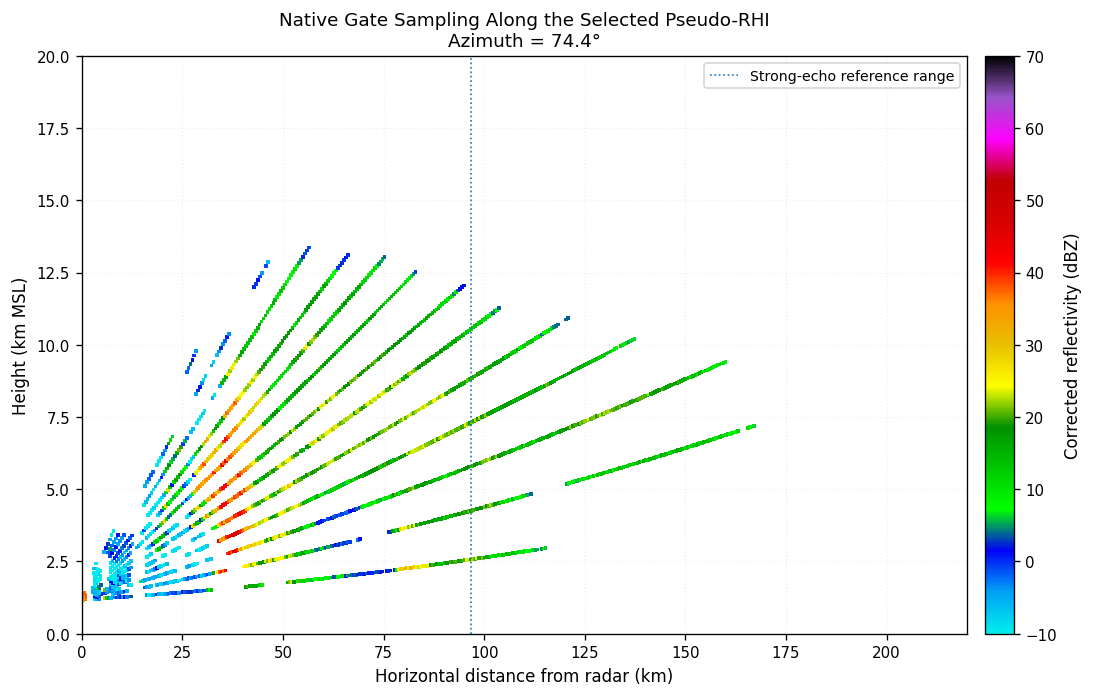

In [20]:
# CELL 20 — Native gate sampling visualization

native_valid = (
    NATIVE_PSEUDO_RHI_TABLE.loc[
        NATIVE_PSEUDO_RHI_TABLE[
            "corrected_ZH_dBZ"
        ].notna()
        & (
            NATIVE_PSEUDO_RHI_TABLE[
                "horizontal_range_km"
            ]
            <= SECTION_MAX_RANGE_KM
        )
        & (
            NATIVE_PSEUDO_RHI_TABLE[
                "height_km_MSL"
            ]
            <= VERTICAL_DISPLAY_MAX_KM_MSL
        )
    ]
)

fig = plt.figure(
    figsize=(
        9.0,
        5.7,
    )
)

ax = fig.add_subplot(
    111
)

scatter = ax.scatter(
    native_valid[
        "horizontal_range_km"
    ],
    native_valid[
        "height_km_MSL"
    ],
    c=(
        native_valid[
            "corrected_ZH_dBZ"
        ]
    ),
    cmap=(
        ZH_CMAP
    ),
    vmin=(
        ZH_VMIN
    ),
    vmax=(
        ZH_VMAX
    ),
    marker="s",
    s=5,
    linewidths=0,
    rasterized=True,
)

cbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Corrected reflectivity (dBZ)"
)

ax.axvline(
    CORE_REFERENCE_RANGE_KM,
    linestyle=":",
    linewidth=1.0,
    label="Strong-echo reference range",
)

for label, height_km in (
    THERMAL_LEVELS.items()
):
    ax.axhline(
        height_km,
        linestyle="--",
        linewidth=0.9,
        alpha=0.80,
        label=label,
    )

ax.set_xlim(
    0.0,
    SECTION_MAX_RANGE_KM,
)

ax.set_ylim(
    0.0,
    VERTICAL_DISPLAY_MAX_KM_MSL,
)

ax.set_xlabel(
    "Horizontal distance from radar (km)"
)

ax.set_ylabel(
    "Height (km MSL)"
)

ax.set_title(
    (
        "Native Gate Sampling Along the Selected Pseudo-RHI\n"
        f"Azimuth = {TARGET_AZIMUTH_DEG:.1f}°"
    )
)

ax.grid(
    alpha=0.18,
    linestyle=":",
)

ax.legend(
    loc="upper right",
    frameon=True,
    ncol=2,
)

F = (
    FIGURE_DIR
    / "06_fig04_native_gate_sampling.png"
)

save_figure(
    fig,
    F,
    product="native pseudo-RHI gate sampling",
    source_file=(
        SELECTED_FILENAME
    ),
    target_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    field=(
        FIELD_Z
    ),
    units="dBZ",
)

plt.show()

# 18. สร้าง Cartesian radial cross section

Storm-focused grid จาก Notebook 03 มี:

```text
horizontal spacing ≈ 0.5 km
vertical spacing   ≈ 0.5 km
```

แต่ต้องจำว่า:

```text
0.5-km grid spacing
≠
0.5-km independent radar observations
```

เราจะ sample grid ตามแนว:

$$
x=s\sin(\theta)
$$

$$
y=s\cos(\theta)
$$

โดย:

- $s$ = horizontal distance from radar
- $\theta$ = target azimuth

จากนั้น interpolate ในแต่ละ Cartesian height layer

In [21]:
# CELL 21 — Extract storm-grid coordinates

storm_x_km = (
    np.asarray(
        storm_grid.x[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

storm_y_km = (
    np.asarray(
        storm_grid.y[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

storm_z_km = (
    np.asarray(
        storm_grid.z[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

storm_zh = np.ma.asarray(
    storm_grid.fields[
        FIELD_Z
    ][
        "data"
    ]
)

print(
    "Storm-grid x:",
    f"{storm_x_km.min():.1f} to {storm_x_km.max():.1f} km",
)

print(
    "Storm-grid y:",
    f"{storm_y_km.min():.1f} to {storm_y_km.max():.1f} km",
)

print(
    "Storm-grid z:",
    f"{storm_z_km.min():.1f} to {storm_z_km.max():.1f} km MSL",
)

Storm-grid x: -20.5 to 190.0 km
Storm-grid y: -52.5 to 111.5 km
Storm-grid z: 1.5 to 20.0 km MSL


In [22]:
# CELL 22 — Radial Cartesian cross-section sampler

def sample_cartesian_radial_section(
    grid_object,
    field_name,
    *,
    azimuth_deg,
    spacing_km=0.5,
    maximum_range_km=220.0,
):
    x_km = (
        np.asarray(
            grid_object.x[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    y_km = (
        np.asarray(
            grid_object.y[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    z_km = (
        np.asarray(
            grid_object.z[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    field = np.ma.asarray(
        grid_object.fields[
            field_name
        ][
            "data"
        ]
    )

    distance_km = np.arange(
        0.0,
        maximum_range_km
        + spacing_km
        / 2.0,
        spacing_km,
    )

    theta = np.deg2rad(
        azimuth_deg
    )

    line_x_km = (
        distance_km
        * np.sin(
            theta
        )
    )

    line_y_km = (
        distance_km
        * np.cos(
            theta
        )
    )

    inside_xy = (
        (
            line_x_km
            >= x_km.min()
        )
        & (
            line_x_km
            <= x_km.max()
        )
        & (
            line_y_km
            >= y_km.min()
        )
        & (
            line_y_km
            <= y_km.max()
        )
    )

    section = np.full(
        (
            len(
                z_km
            ),
            len(
                distance_km
            ),
        ),
        np.nan,
        dtype=float,
    )

    interpolation_points = np.column_stack(
        [
            line_y_km,
            line_x_km,
        ]
    )

    for level_index in range(
        len(
            z_km
        )
    ):
        layer = np.ma.asarray(
            field[
                level_index
            ]
        ).filled(
            np.nan
        )

        interpolator = (
            RegularGridInterpolator(
                (
                    y_km,
                    x_km,
                ),
                layer,
                bounds_error=False,
                fill_value=np.nan,
            )
        )

        values = interpolator(
            interpolation_points
        )

        values[
            ~inside_xy
        ] = np.nan

        section[
            level_index
        ] = values

    valid_columns = np.any(
        np.isfinite(
            section
        ),
        axis=0,
    )

    if not valid_columns.any():
        raise RuntimeError(
            "แนว cross section ไม่ตัดผ่าน valid storm-grid domain"
        )

    first_valid = int(
        np.where(
            valid_columns
        )[0][0]
    )

    last_valid = int(
        np.where(
            valid_columns
        )[0][-1]
    )

    sl = slice(
        first_valid,
        last_valid
        + 1,
    )

    return {
        "azimuth_deg": float(
            azimuth_deg
        ),
        "distance_km": (
            distance_km[
                sl
            ]
        ),
        "x_km": (
            line_x_km[
                sl
            ]
        ),
        "y_km": (
            line_y_km[
                sl
            ]
        ),
        "z_km_MSL": (
            z_km
        ),
        "field": (
            section[
                :,
                sl
            ]
        ),
    }

In [23]:
# CELL 23 — Main Cartesian section

MAIN_SECTION = (
    sample_cartesian_radial_section(
        storm_grid,
        FIELD_Z,
        azimuth_deg=(
            TARGET_AZIMUTH_DEG
        ),
        spacing_km=(
            SECTION_SPACING_KM
        ),
        maximum_range_km=(
            SECTION_MAX_RANGE_KM
        ),
    )
)

SECTION_DISTANCE_KM = (
    MAIN_SECTION[
        "distance_km"
    ]
)

SECTION_Z_KM = (
    MAIN_SECTION[
        "z_km_MSL"
    ]
)

SECTION_ZH = (
    MAIN_SECTION[
        "field"
    ]
)

print(
    "Section range:",
    f"{SECTION_DISTANCE_KM.min():.1f}–"
    f"{SECTION_DISTANCE_KM.max():.1f} km",
)

print(
    "Section shape:",
    SECTION_ZH.shape,
)

Section range: 0.0–169.5 km
Section shape: (38, 340)


# 19. Cartesian cross-section figure

Figure จะใช้:

- corrected reflectivity
- 30/40/50/55/60-dBZ contours
- strong-echo reference range
- optional 0/−10/−20/−30°C levels
- MSL vertical reference

Contours ช่วยให้เห็น strong-core depth มากกว่าดูสีเพียงอย่างเดียว

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig05_cartesian_vertical_cross_section.png


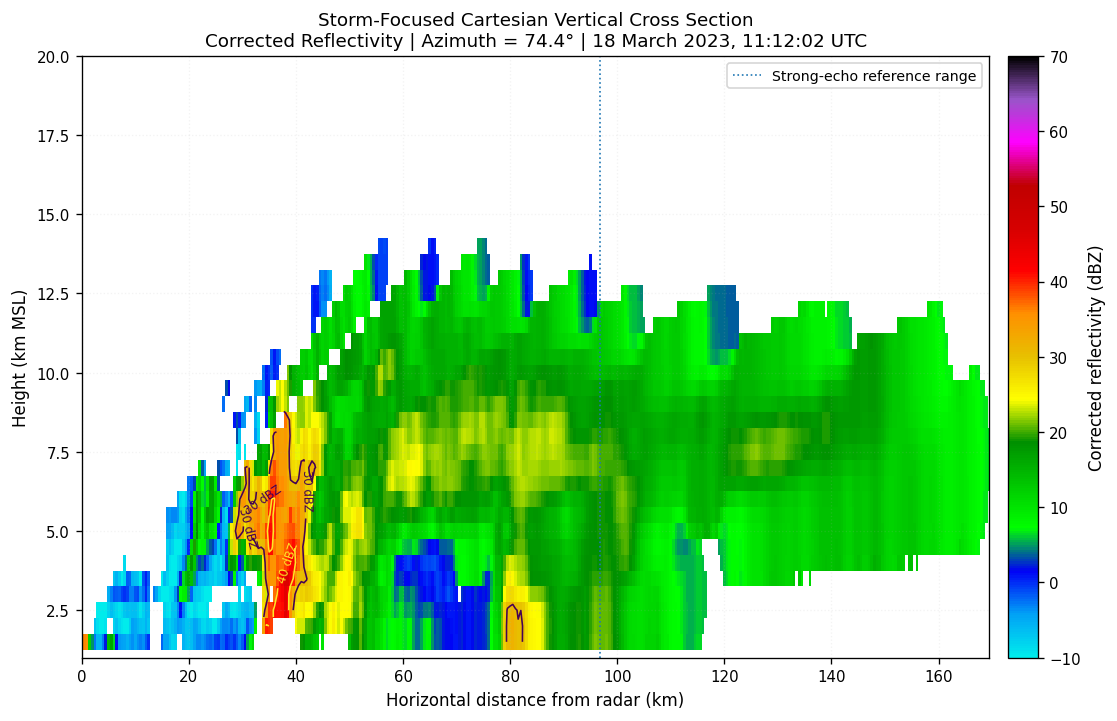

In [24]:
# CELL 24 — Professional Cartesian vertical cross section

fig = plt.figure(
    figsize=(
        9.2,
        5.9,
    )
)

ax = fig.add_subplot(
    111
)

mesh = ax.pcolormesh(
    SECTION_DISTANCE_KM,
    SECTION_Z_KM,
    np.ma.masked_invalid(
        SECTION_ZH
    ),
    shading="auto",
    cmap=(
        ZH_CMAP
    ),
    vmin=(
        ZH_VMIN
    ),
    vmax=(
        ZH_VMAX
    ),
    rasterized=True,
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "Corrected reflectivity (dBZ)"
)

finite_section = SECTION_ZH[
    np.isfinite(
        SECTION_ZH
    )
]

if finite_section.size:
    usable_contours = [
        level
        for level in (
            REFLECTIVITY_CONTOURS_DBZ
        )
        if (
            np.nanmin(
                finite_section
            )
            <= level
            <= np.nanmax(
                finite_section
            )
        )
    ]

    if usable_contours:
        contours = ax.contour(
            SECTION_DISTANCE_KM,
            SECTION_Z_KM,
            SECTION_ZH,
            levels=(
                usable_contours
            ),
            linewidths=0.95,
        )

        ax.clabel(
            contours,
            fmt=lambda value: (
                f"{value:.0f} dBZ"
            ),
            fontsize=7,
            inline=True,
        )

ax.axvline(
    CORE_REFERENCE_RANGE_KM,
    linestyle=":",
    linewidth=1.0,
    label="Strong-echo reference range",
)

for label, height_km in (
    THERMAL_LEVELS.items()
):
    ax.axhline(
        height_km,
        linestyle="--",
        linewidth=0.9,
        alpha=0.82,
        label=label,
    )

ax.set_xlim(
    SECTION_DISTANCE_KM.min(),
    SECTION_DISTANCE_KM.max(),
)

ax.set_ylim(
    VERTICAL_DISPLAY_MIN_KM_MSL,
    VERTICAL_DISPLAY_MAX_KM_MSL,
)

ax.set_xlabel(
    "Horizontal distance from radar (km)"
)

ax.set_ylabel(
    "Height (km MSL)"
)

ax.set_title(
    (
        "Storm-Focused Cartesian Vertical Cross Section\n"
        f"Corrected Reflectivity | Azimuth = {TARGET_AZIMUTH_DEG:.1f}° | "
        f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')}"
    )
)

ax.grid(
    alpha=0.15,
    linestyle=":",
)

ax.legend(
    loc="upper right",
    frameon=True,
    ncol=2,
)

F = (
    FIGURE_DIR
    / "06_fig05_cartesian_vertical_cross_section.png"
)

save_figure(
    fig,
    F,
    product="Cartesian vertical cross section",
    source_file=(
        SELECTED_FILENAME
    ),
    target_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    field=(
        FIELD_Z
    ),
    processing=(
        "0.5-km storm-focused 3-D Cartesian grid; "
        "radial bilinear sampling in each horizontal layer."
    ),
    units="dBZ",
)

plt.show()

# 20. Export Cartesian cross-section table

เพื่อให้สามารถทำ analysis ภายนอก Notebook ได้ จะ export long-format table:

```text
azimuth
distance_km
height_km_MSL
x_km
y_km
corrected_ZH_dBZ
```

ตารางนี้เป็น **Cartesian interpolated cross section**
ไม่ใช่ native radar gates

In [25]:
# CELL 25 — Export main Cartesian section as long table

cartesian_rows = []

for z_index, height_km in enumerate(
    SECTION_Z_KM
):
    for distance_index, distance_km in enumerate(
        SECTION_DISTANCE_KM
    ):
        value = (
            SECTION_ZH[
                z_index,
                distance_index
            ]
        )

        cartesian_rows.append({
            "azimuth_deg": (
                TARGET_AZIMUTH_DEG
            ),
            "distance_km": float(
                distance_km
            ),
            "height_km_MSL": float(
                height_km
            ),
            "x_km": float(
                MAIN_SECTION[
                    "x_km"
                ][
                    distance_index
                ]
            ),
            "y_km": float(
                MAIN_SECTION[
                    "y_km"
                ][
                    distance_index
                ]
            ),
            "corrected_ZH_dBZ": (
                float(
                    value
                )
                if np.isfinite(
                    value
                )
                else np.nan
            ),
        })


CARTESIAN_SECTION_TABLE = pd.DataFrame(
    cartesian_rows
)

display(
    CARTESIAN_SECTION_TABLE.head()
)

CARTESIAN_SECTION_CSV = (
    OUTPUT_CSV_DIR
    / "06_cartesian_vertical_cross_section.csv"
)

CARTESIAN_SECTION_TABLE.to_csv(
    CARTESIAN_SECTION_CSV,
    index=False,
)

,azimuth_deg,distance_km,height_km_MSL,x_km,y_km,corrected_ZH_dBZ
0,74.374474,0.0,1.5,0.000000,0.000000,33.985886
1,74.374474,0.5,1.5,0.481521,0.134674,36.115932
2,74.374474,1.0,1.5,0.963043,0.269349,35.361596
3,74.374474,1.5,1.5,1.444564,0.404023,12.164402
4,74.374474,2.0,1.5,1.926085,0.538698,4.900706


# 21. Height of maximum reflectivity

สำหรับแต่ละ horizontal distance:

$$
H_{maxZ}(s)
=
z
\left[
\arg\max_z
Z_H(s,z)
\right]
$$

ตัวแปรนี้บอกว่า intense reflectivity ใน column อยู่สูงเท่าใด

แต่ต้องระวัง:

```text
height of maximum ZH
≠
echo top
```

เพราะ echo top พิจารณา highest threshold crossing ส่วน height of max ใช้ตำแหน่งของ maximum value

In [26]:
# CELL 26 — Height and magnitude of maximum ZH along the section

MAX_ZH_ALONG_SECTION = np.full(
    len(
        SECTION_DISTANCE_KM
    ),
    np.nan,
)

HEIGHT_OF_MAX_ZH_KM = np.full(
    len(
        SECTION_DISTANCE_KM
    ),
    np.nan,
)

for index in range(
    len(
        SECTION_DISTANCE_KM
    )
):
    column = (
        SECTION_ZH[
            :,
            index
        ]
    )

    valid = np.isfinite(
        column
    )

    if not valid.any():
        continue

    valid_indices = np.where(
        valid
    )[0]

    local_index = valid_indices[
        np.nanargmax(
            column[
                valid
            ]
        )
    ]

    MAX_ZH_ALONG_SECTION[
        index
    ] = column[
        local_index
    ]

    HEIGHT_OF_MAX_ZH_KM[
        index
    ] = SECTION_Z_KM[
        local_index
    ]


HEIGHT_MAX_TABLE = pd.DataFrame({
    "distance_km": (
        SECTION_DISTANCE_KM
    ),
    "max_ZH_dBZ": (
        MAX_ZH_ALONG_SECTION
    ),
    "height_of_max_ZH_km_MSL": (
        HEIGHT_OF_MAX_ZH_KM
    ),
})

display(
    HEIGHT_MAX_TABLE.head()
)

HEIGHT_MAX_CSV = (
    OUTPUT_CSV_DIR
    / "06_height_of_max_reflectivity_along_section.csv"
)

HEIGHT_MAX_TABLE.to_csv(
    HEIGHT_MAX_CSV,
    index=False,
)

,distance_km,max_ZH_dBZ,height_of_max_ZH_km_MSL
0,0.0,33.985886,1.5
1,0.5,36.115932,1.5
2,1.0,35.361596,1.5
3,1.5,12.164402,1.5
4,2.0,4.900706,1.5


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig06_height_of_max_reflectivity.png


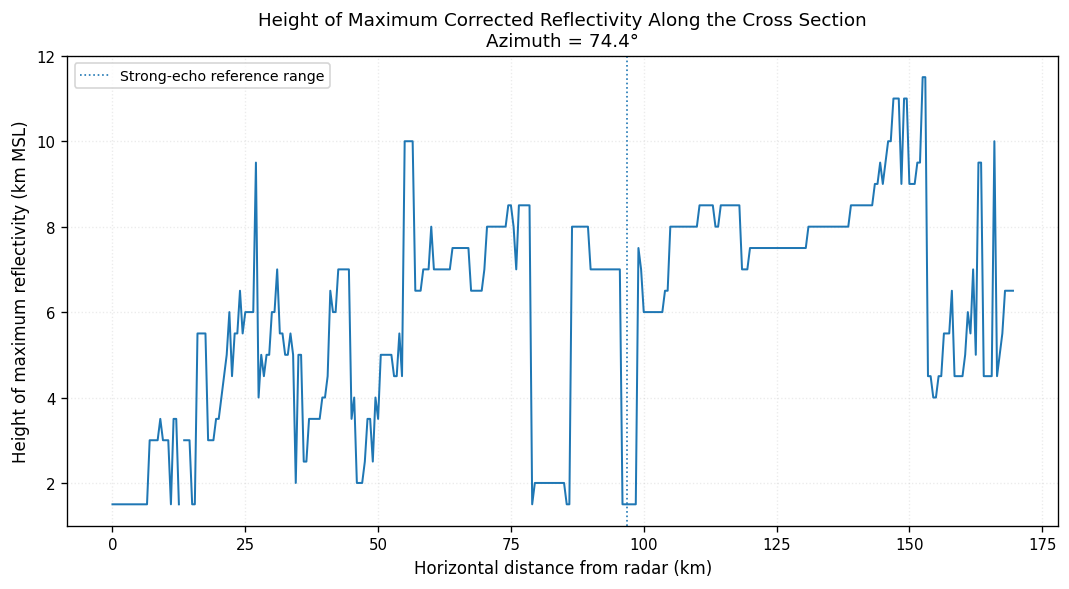

In [27]:
# CELL 27 — Height of maximum reflectivity figure

fig = plt.figure(
    figsize=(
        8.8,
        4.8,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    SECTION_DISTANCE_KM,
    HEIGHT_OF_MAX_ZH_KM,
)

ax.axvline(
    CORE_REFERENCE_RANGE_KM,
    linestyle=":",
    linewidth=1.0,
    label="Strong-echo reference range",
)

for label, height_km in (
    THERMAL_LEVELS.items()
):
    ax.axhline(
        height_km,
        linestyle="--",
        linewidth=0.8,
        alpha=0.75,
        label=label,
    )

ax.set_xlabel(
    "Horizontal distance from radar (km)"
)

ax.set_ylabel(
    "Height of maximum reflectivity (km MSL)"
)

ax.set_title(
    (
        "Height of Maximum Corrected Reflectivity Along the Cross Section\n"
        f"Azimuth = {TARGET_AZIMUTH_DEG:.1f}°"
    )
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
    ncol=2,
)

F = (
    FIGURE_DIR
    / "06_fig06_height_of_max_reflectivity.png"
)

save_figure(
    fig,
    F,
    product="height of maximum reflectivity",
    source_file=(
        SELECTED_FILENAME
    ),
    target_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    units="km MSL",
)

plt.show()

# 22. Threshold-top และ radar echo-base preview

สำหรับ cross section ที่เลือก จะคำนวณระดับสูงสุดที่ reflectivity ผ่าน threshold:

$$
z_{top,T}(s)
=
\max
\left\{
z:
Z_H(s,z)\ge T
\right\}
$$

และระดับต่ำสุดที่ผ่าน threshold:

$$
z_{base,T}(s)
=
\min
\left\{
z:
Z_H(s,z)\ge T
\right\}
$$

ใน Notebook 06 ค่าเหล่านี้เป็น **cross-section threshold-top / echo-base preview**

ยังไม่ใช่ final 2-D echo-top product ของ Notebook 07

# 23. Censoring ที่ขอบ grid

หาก threshold ยังมีอยู่ที่ระดับบนสุดของ grid:

```text
top = 20 km MSL
```

เราไม่ทราบว่า echo สิ้นสุดที่ 20 km จริงหรือสูงกว่านั้น

จึงเรียกว่า:

```text
top-censored
```

เช่นเดียวกัน หาก echo เริ่มตั้งแต่ grid level ล่างสุด:

```text
base-censored
```

แปลว่า radar echo base อาจอยู่ต่ำกว่าขอบล่างของ grid

การไม่รายงาน censoring สามารถทำให้ storm depth ถูกตีความผิด

In [28]:
# CELL 28 — Threshold-top and echo-base calculator

def threshold_top_and_base(
    section,
    z_km,
    threshold_dbz,
):
    n_distance = (
        section.shape[
            1
        ]
    )

    top_km = np.full(
        n_distance,
        np.nan,
    )

    base_km = np.full(
        n_distance,
        np.nan,
    )

    top_censored = np.zeros(
        n_distance,
        dtype=bool,
    )

    base_censored = np.zeros(
        n_distance,
        dtype=bool,
    )

    for index in range(
        n_distance
    ):
        column = (
            section[
                :,
                index
            ]
        )

        valid_hits = np.where(
            np.isfinite(
                column
            )
            & (
                column
                >= threshold_dbz
            )
        )[0]

        if valid_hits.size == 0:
            continue

        bottom_index = int(
            valid_hits[
                0
            ]
        )

        top_index = int(
            valid_hits[
                -1
            ]
        )

        base_km[
            index
        ] = z_km[
            bottom_index
        ]

        top_km[
            index
        ] = z_km[
            top_index
        ]

        base_censored[
            index
        ] = (
            bottom_index
            == 0
        )

        top_censored[
            index
        ] = (
            top_index
            == len(
                z_km
            )
            - 1
        )

    return {
        "top_km_MSL": (
            top_km
        ),
        "base_km_MSL": (
            base_km
        ),
        "top_censored": (
            top_censored
        ),
        "base_censored": (
            base_censored
        ),
    }

In [29]:
# CELL 29 — Calculate threshold-top previews

THRESHOLD_PRODUCTS = {}

threshold_rows = []

for threshold in (
    THRESHOLD_TOPS_DBZ
):
    product = (
        threshold_top_and_base(
            SECTION_ZH,
            SECTION_Z_KM,
            threshold,
        )
    )

    THRESHOLD_PRODUCTS[
        threshold
    ] = product

    for index, distance_km in enumerate(
        SECTION_DISTANCE_KM
    ):
        threshold_rows.append({
            "threshold_dBZ": (
                threshold
            ),
            "distance_km": float(
                distance_km
            ),
            "top_height_km_MSL": (
                float(
                    product[
                        "top_km_MSL"
                    ][
                        index
                    ]
                )
                if np.isfinite(
                    product[
                        "top_km_MSL"
                    ][
                        index
                    ]
                )
                else np.nan
            ),
            "base_height_km_MSL": (
                float(
                    product[
                        "base_km_MSL"
                    ][
                        index
                    ]
                )
                if np.isfinite(
                    product[
                        "base_km_MSL"
                    ][
                        index
                    ]
                )
                else np.nan
            ),
            "top_censored": bool(
                product[
                    "top_censored"
                ][
                    index
                ]
            ),
            "base_censored": bool(
                product[
                    "base_censored"
                ][
                    index
                ]
            ),
        })


THRESHOLD_TOP_TABLE = pd.DataFrame(
    threshold_rows
)

display(
    THRESHOLD_TOP_TABLE.head()
)

THRESHOLD_TOP_CSV = (
    OUTPUT_CSV_DIR
    / "06_cross_section_threshold_top_base.csv"
)

THRESHOLD_TOP_TABLE.to_csv(
    THRESHOLD_TOP_CSV,
    index=False,
)

,threshold_dBZ,distance_km,top_height_km_MSL,base_height_km_MSL,top_censored,base_censored
0,20.0,0.0,1.5,1.5,False,True
1,20.0,0.5,1.5,1.5,False,True
2,20.0,1.0,1.5,1.5,False,True
3,20.0,1.5,NaN,NaN,False,False
4,20.0,2.0,NaN,NaN,False,False


In [30]:
# CELL 30 — Threshold-top summary

threshold_summary_rows = []

for threshold in (
    THRESHOLD_TOPS_DBZ
):
    product = (
        THRESHOLD_PRODUCTS[
            threshold
        ]
    )

    top_values = (
        product[
            "top_km_MSL"
        ]
    )

    finite = np.isfinite(
        top_values
    )

    threshold_summary_rows.append({
        "threshold_dBZ": (
            threshold
        ),
        "n_columns_present": int(
            finite.sum()
        ),
        "maximum_top_height_km_MSL": (
            float(
                np.nanmax(
                    top_values
                )
            )
            if finite.any()
            else np.nan
        ),
        "median_top_height_km_MSL": (
            float(
                np.nanmedian(
                    top_values[
                        finite
                    ]
                )
            )
            if finite.any()
            else np.nan
        ),
        "top_censored_column_count": int(
            product[
                "top_censored"
            ].sum()
        ),
        "base_censored_column_count": int(
            product[
                "base_censored"
            ].sum()
        ),
    })


THRESHOLD_TOP_SUMMARY = pd.DataFrame(
    threshold_summary_rows
)

display(
    THRESHOLD_TOP_SUMMARY
)

THRESHOLD_TOP_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "06_cross_section_threshold_top_summary.csv"
)

THRESHOLD_TOP_SUMMARY.to_csv(
    THRESHOLD_TOP_SUMMARY_CSV,
    index=False,
)

,threshold_dBZ,n_columns_present,maximum_top_height_km_MSL,median_top_height_km_MSL,top_censored_column_count,base_censored_column_count
0,20.0,169,10.5,8.0,0,29
1,30.0,39,8.5,6.0,0,9
2,40.0,11,6.0,4.0,0,0
3,50.0,0,NaN,NaN,0,0


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig07_cross_section_threshold_top_preview.png


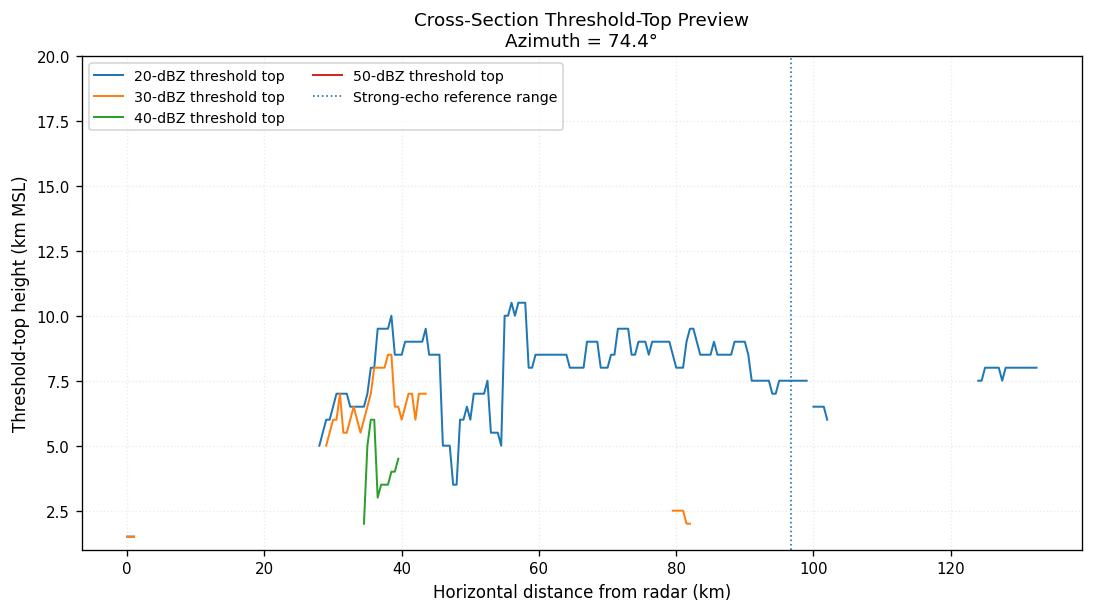

In [31]:
# CELL 31 — Threshold-top preview figure

fig = plt.figure(
    figsize=(
        9.0,
        5.0,
    )
)

ax = fig.add_subplot(
    111
)

for threshold in (
    THRESHOLD_TOPS_DBZ
):
    product = (
        THRESHOLD_PRODUCTS[
            threshold
        ]
    )

    ax.plot(
        SECTION_DISTANCE_KM,
        product[
            "top_km_MSL"
        ],
        label=(
            f"{threshold:.0f}-dBZ threshold top"
        ),
    )

ax.axvline(
    CORE_REFERENCE_RANGE_KM,
    linestyle=":",
    linewidth=1.0,
    label="Strong-echo reference range",
)

for label, height_km in (
    THERMAL_LEVELS.items()
):
    ax.axhline(
        height_km,
        linestyle="--",
        linewidth=0.8,
        alpha=0.75,
        label=label,
    )

ax.set_xlabel(
    "Horizontal distance from radar (km)"
)

ax.set_ylabel(
    "Threshold-top height (km MSL)"
)

ax.set_ylim(
    VERTICAL_DISPLAY_MIN_KM_MSL,
    VERTICAL_DISPLAY_MAX_KM_MSL,
)

ax.set_title(
    (
        "Cross-Section Threshold-Top Preview\n"
        f"Azimuth = {TARGET_AZIMUTH_DEG:.1f}°"
    )
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
    ncol=2,
)

F = (
    FIGURE_DIR
    / "06_fig07_cross_section_threshold_top_preview.png"
)

save_figure(
    fig,
    F,
    product="cross-section threshold-top preview",
    source_file=(
        SELECTED_FILENAME
    ),
    target_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    processing=(
        "Highest 0.5-km Cartesian grid level meeting each reflectivity threshold."
    ),
    units="km MSL",
)

plt.show()

# 24. Radar echo-base preview และ storm depth

สำหรับ threshold 20 dBZ:

$$
D_{20}(s)
=
z_{top,20}(s)
-
z_{base,20}(s)
$$

เรียกว่า **20-dBZ echo depth** ใน selected cross section

แต่หาก base ถูก censored ที่ระดับล่างสุดของ grid:

```text
echo depth is a lower-bound estimate
```

และไม่ควรเรียก base ว่า cloud base

In [32]:
# CELL 32 — 20-dBZ echo-depth calculation

base20 = (
    THRESHOLD_PRODUCTS[
        ECHO_BASE_THRESHOLD_DBZ
    ][
        "base_km_MSL"
    ]
)

top20 = (
    THRESHOLD_PRODUCTS[
        ECHO_BASE_THRESHOLD_DBZ
    ][
        "top_km_MSL"
    ]
)

ECHO_DEPTH20_KM = (
    top20
    - base20
)

ECHO_DEPTH20_TABLE = pd.DataFrame({
    "distance_km": (
        SECTION_DISTANCE_KM
    ),
    "echo_base_20dBZ_km_MSL": (
        base20
    ),
    "echo_top_20dBZ_km_MSL": (
        top20
    ),
    "echo_depth_20dBZ_km": (
        ECHO_DEPTH20_KM
    ),
    "base_censored": (
        THRESHOLD_PRODUCTS[
            ECHO_BASE_THRESHOLD_DBZ
        ][
            "base_censored"
        ]
    ),
    "top_censored": (
        THRESHOLD_PRODUCTS[
            ECHO_BASE_THRESHOLD_DBZ
        ][
            "top_censored"
        ]
    ),
})

display(
    ECHO_DEPTH20_TABLE.head()
)

ECHO_DEPTH20_CSV = (
    OUTPUT_CSV_DIR
    / "06_cross_section_echo_depth_20dBZ.csv"
)

ECHO_DEPTH20_TABLE.to_csv(
    ECHO_DEPTH20_CSV,
    index=False,
)

,distance_km,echo_base_20dBZ_km_MSL,echo_top_20dBZ_km_MSL,echo_depth_20dBZ_km,base_censored,top_censored
0,0.0,1.5,1.5,0.0,True,False
1,0.5,1.5,1.5,0.0,True,False
2,1.0,1.5,1.5,0.0,True,False
3,1.5,NaN,NaN,NaN,False,False
4,2.0,NaN,NaN,NaN,False,False


# 25. Vertical profile ผ่าน intense core

การดู cross section ทั้งภาพอาจทำให้ยากต่อการระบุว่า strongest column มี vertical structure อย่างไร

Notebook จะหา location ของ maximum corrected reflectivity ใน selected Cartesian section แล้วสร้าง vertical profile:

```text
ZH
vs
height MSL
```

จาก profile นี้จะรายงาน:

- maximum ZH
- height of maximum ZH
- threshold-top heights
- threshold-base heights

In [33]:
# CELL 33 — Find strongest point in the Cartesian section

finite_mask = np.isfinite(
    SECTION_ZH
)

if not finite_mask.any():
    raise RuntimeError(
        "Cartesian cross section ไม่มี valid reflectivity"
    )

flat_index = int(
    np.nanargmax(
        SECTION_ZH
    )
)

max_z_index, max_distance_index = (
    np.unravel_index(
        flat_index,
        SECTION_ZH.shape,
    )
)

SECTION_MAX_ZH_DBZ = float(
    SECTION_ZH[
        max_z_index,
        max_distance_index
    ]
)

SECTION_MAX_ZH_HEIGHT_KM_MSL = float(
    SECTION_Z_KM[
        max_z_index
    ]
)

SECTION_MAX_ZH_DISTANCE_KM = float(
    SECTION_DISTANCE_KM[
        max_distance_index
    ]
)

CORE_VERTICAL_PROFILE = (
    SECTION_ZH[
        :,
        max_distance_index
    ]
)

print(
    "Section maximum ZH:",
    f"{SECTION_MAX_ZH_DBZ:.1f} dBZ",
)

print(
    "Distance:",
    f"{SECTION_MAX_ZH_DISTANCE_KM:.1f} km",
)

print(
    "Height:",
    f"{SECTION_MAX_ZH_HEIGHT_KM_MSL:.1f} km MSL",
)

Section maximum ZH: 46.4 dBZ
Distance: 38.0 km
Height: 3.5 km MSL


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig08_strongest_column_vertical_profile.png


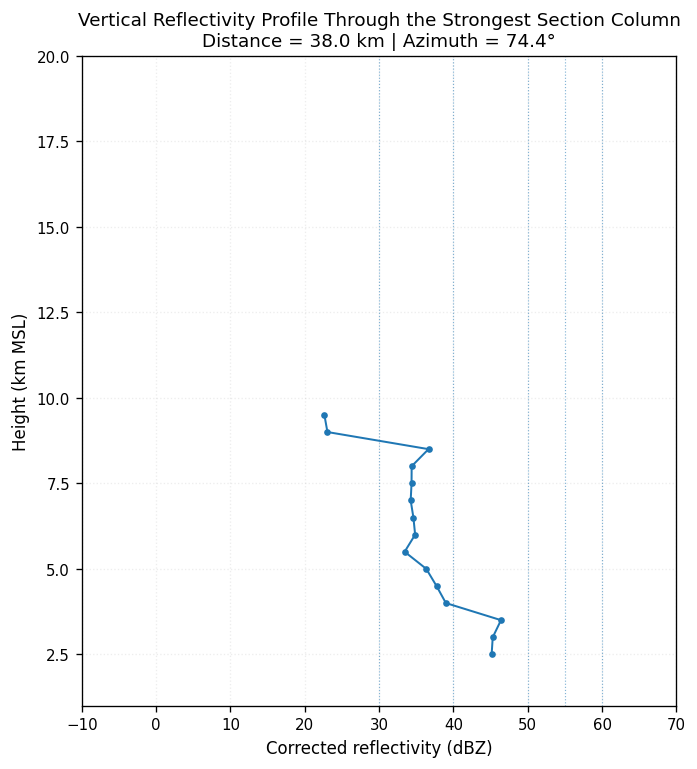

In [34]:
# CELL 34 — Strongest-column vertical profile figure

fig = plt.figure(
    figsize=(
        5.7,
        6.3,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    CORE_VERTICAL_PROFILE,
    SECTION_Z_KM,
    marker="o",
    markersize=3,
)

for threshold in (
    REFLECTIVITY_CONTOURS_DBZ
):
    ax.axvline(
        threshold,
        linestyle=":",
        linewidth=0.7,
        alpha=0.55,
    )

for label, height_km in (
    THERMAL_LEVELS.items()
):
    ax.axhline(
        height_km,
        linestyle="--",
        linewidth=0.9,
        alpha=0.78,
        label=label,
    )

ax.set_xlim(
    ZH_VMIN,
    ZH_VMAX,
)

ax.set_ylim(
    VERTICAL_DISPLAY_MIN_KM_MSL,
    VERTICAL_DISPLAY_MAX_KM_MSL,
)

ax.set_xlabel(
    "Corrected reflectivity (dBZ)"
)

ax.set_ylabel(
    "Height (km MSL)"
)

ax.set_title(
    (
        "Vertical Reflectivity Profile Through the Strongest Section Column\n"
        f"Distance = {SECTION_MAX_ZH_DISTANCE_KM:.1f} km | "
        f"Azimuth = {TARGET_AZIMUTH_DEG:.1f}°"
    )
)

ax.grid(
    alpha=0.22,
    linestyle=":",
)

if THERMAL_LEVELS_AVAILABLE:
    ax.legend(
        frameon=True,
    )

F = (
    FIGURE_DIR
    / "06_fig08_strongest_column_vertical_profile.png"
)

save_figure(
    fig,
    F,
    product="strongest-column vertical profile",
    source_file=(
        SELECTED_FILENAME
    ),
    target_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    distance_km=(
        SECTION_MAX_ZH_DISTANCE_KM
    ),
    units="dBZ",
)

plt.show()

In [35]:
# CELL 35 — Strongest-column summary table

core_summary = {
    "target_azimuth_deg": (
        TARGET_AZIMUTH_DEG
    ),
    "strongest_column_distance_km": (
        SECTION_MAX_ZH_DISTANCE_KM
    ),
    "maximum_ZH_dBZ": (
        SECTION_MAX_ZH_DBZ
    ),
    "height_of_maximum_ZH_km_MSL": (
        SECTION_MAX_ZH_HEIGHT_KM_MSL
    ),
}

for threshold in (
    THRESHOLD_TOPS_DBZ
):
    product = (
        THRESHOLD_PRODUCTS[
            threshold
        ]
    )

    core_summary[
        f"top_{int(threshold)}dBZ_km_MSL"
    ] = (
        product[
            "top_km_MSL"
        ][
            max_distance_index
        ]
    )

    core_summary[
        f"base_{int(threshold)}dBZ_km_MSL"
    ] = (
        product[
            "base_km_MSL"
        ][
            max_distance_index
        ]
    )


CORE_VERTICAL_SUMMARY = pd.DataFrame(
    [
        core_summary
    ]
)

display(
    CORE_VERTICAL_SUMMARY
)

CORE_VERTICAL_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "06_strongest_column_vertical_structure.csv"
)

CORE_VERTICAL_SUMMARY.to_csv(
    CORE_VERTICAL_SUMMARY_CSV,
    index=False,
)

,target_azimuth_deg,strongest_column_distance_km,maximum_ZH_dBZ,height_of_maximum_ZH_km_MSL,top_20dBZ_km_MSL,base_20dBZ_km_MSL,top_30dBZ_km_MSL,base_30dBZ_km_MSL,top_40dBZ_km_MSL,base_40dBZ_km_MSL,top_50dBZ_km_MSL,base_50dBZ_km_MSL
0,74.374474,38.0,46.394373,3.5,9.5,2.5,8.5,2.5,3.5,2.5,NaN,NaN


# 26. EXPERIMENT — Azimuth sensitivity

Vertical cross section เป็นการตัดพายุด้วยระนาบหนึ่งระนาบ

หากแนวตัดเลื่อนเพียงไม่กี่องศา อาจ:

- ตัดผ่าน core โดยตรง
- ตัดผ่าน flank
- พลาด strongest updraft/hail-growth region

Notebook จะเปรียบเทียบ:

```text
target − 4°
target
target + 4°
```

ด้วย metrics:

- maximum ZH
- height of maximum ZH
- maximum 40-dBZ top
- maximum 50-dBZ top
- vertical-plane area ≥40 dBZ
- vertical-plane area ≥50 dBZ

พื้นที่ใน cross section มีหน่วย km² ของ **vertical plane**
ไม่ใช่ horizontal storm area และไม่ใช่ storm volume

In [36]:
# CELL 36 — Azimuth-sensitivity analysis

AZIMUTH_SECTIONS = {}

azimuth_rows = []

vertical_spacing_km = float(
    np.nanmedian(
        np.diff(
            storm_z_km
        )
    )
)

for azimuth_deg in (
    AZIMUTH_EXPERIMENT_DEG
):
    section_i = (
        sample_cartesian_radial_section(
            storm_grid,
            FIELD_Z,
            azimuth_deg=(
                azimuth_deg
            ),
            spacing_km=(
                SECTION_SPACING_KM
            ),
            maximum_range_km=(
                SECTION_MAX_RANGE_KM
            ),
        )
    )

    AZIMUTH_SECTIONS[
        azimuth_deg
    ] = section_i

    values = (
        section_i[
            "field"
        ]
    )

    finite = np.isfinite(
        values
    )

    if finite.any():
        maximum_zh = float(
            np.nanmax(
                values
            )
        )

        flat_max = int(
            np.nanargmax(
                values
            )
        )

        max_z_i, max_s_i = np.unravel_index(
            flat_max,
            values.shape,
        )

        max_height = float(
            section_i[
                "z_km_MSL"
            ][
                max_z_i
            ]
        )

        max_distance = float(
            section_i[
                "distance_km"
            ][
                max_s_i
            ]
        )

    else:
        maximum_zh = np.nan
        max_height = np.nan
        max_distance = np.nan

    row = {
        "azimuth_deg": (
            azimuth_deg
        ),
        "offset_from_reference_deg": float(
            (
                (
                    azimuth_deg
                    - TARGET_AZIMUTH_DEG
                    + 180.0
                )
                % 360.0
            )
            - 180.0
        ),
        "maximum_ZH_dBZ": (
            maximum_zh
        ),
        "height_of_maximum_ZH_km_MSL": (
            max_height
        ),
        "distance_of_maximum_ZH_km": (
            max_distance
        ),
    }

    for threshold in [
        40.0,
        50.0,
    ]:
        product = (
            threshold_top_and_base(
                values,
                section_i[
                    "z_km_MSL"
                ],
                threshold,
            )
        )

        top = (
            product[
                "top_km_MSL"
            ]
        )

        row[
            f"maximum_{int(threshold)}dBZ_top_km_MSL"
        ] = (
            float(
                np.nanmax(
                    top
                )
            )
            if np.isfinite(
                top
            ).any()
            else np.nan
        )

        vertical_plane_area = float(
            (
                np.isfinite(
                    values
                )
                & (
                    values
                    >= threshold
                )
            ).sum()
            * SECTION_SPACING_KM
            * vertical_spacing_km
        )

        row[
            f"vertical_plane_area_ge_{int(threshold)}dBZ_km2"
        ] = (
            vertical_plane_area
        )

    azimuth_rows.append(
        row
    )


AZIMUTH_SENSITIVITY = pd.DataFrame(
    azimuth_rows
)

display(
    AZIMUTH_SENSITIVITY
)

AZIMUTH_SENSITIVITY_CSV = (
    OUTPUT_CSV_DIR
    / "06_azimuth_sensitivity.csv"
)

AZIMUTH_SENSITIVITY.to_csv(
    AZIMUTH_SENSITIVITY_CSV,
    index=False,
)

,azimuth_deg,offset_from_reference_deg,maximum_ZH_dBZ,height_of_maximum_ZH_km_MSL,distance_of_maximum_ZH_km,maximum_40dBZ_top_km_MSL,vertical_plane_area_ge_40dBZ_km2,maximum_50dBZ_top_km_MSL,vertical_plane_area_ge_50dBZ_km2
0,70.374474,-4.0,51.004489,6.0,137.0,8.5,42.25,6.5,0.75
1,74.374474,0.0,46.394373,3.5,38.0,6.0,7.25,NaN,0.00
2,78.374474,4.0,56.113735,1.5,31.5,9.5,26.50,2.5,2.25


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_azimuth_sensitivity_70.4deg.png


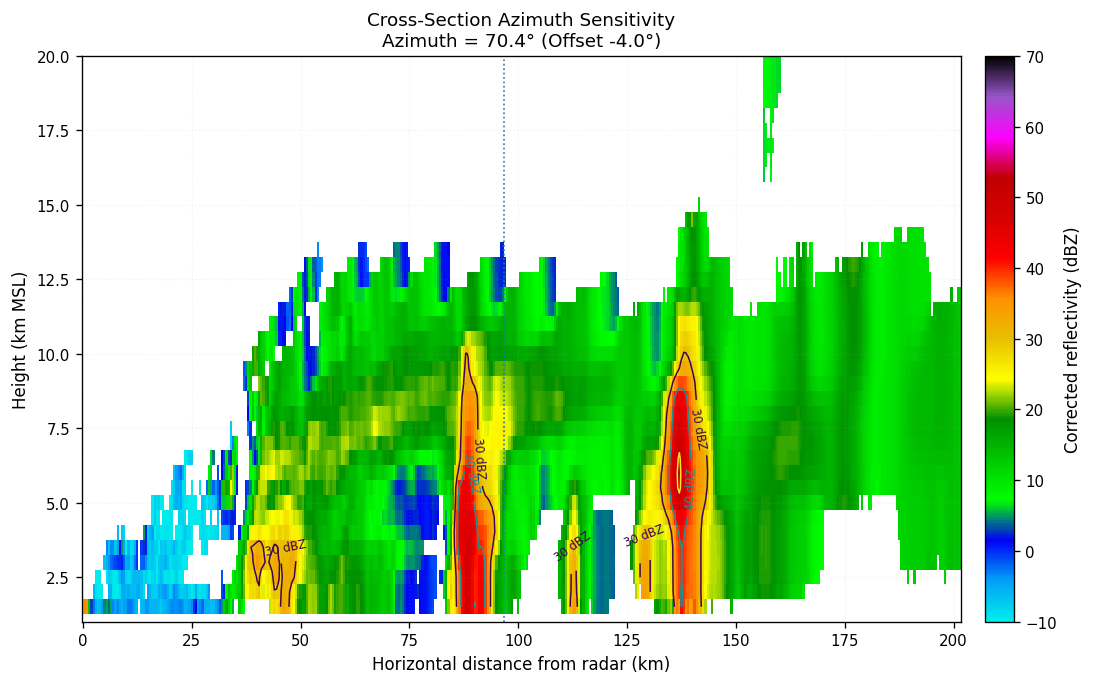

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_azimuth_sensitivity_74.4deg.png


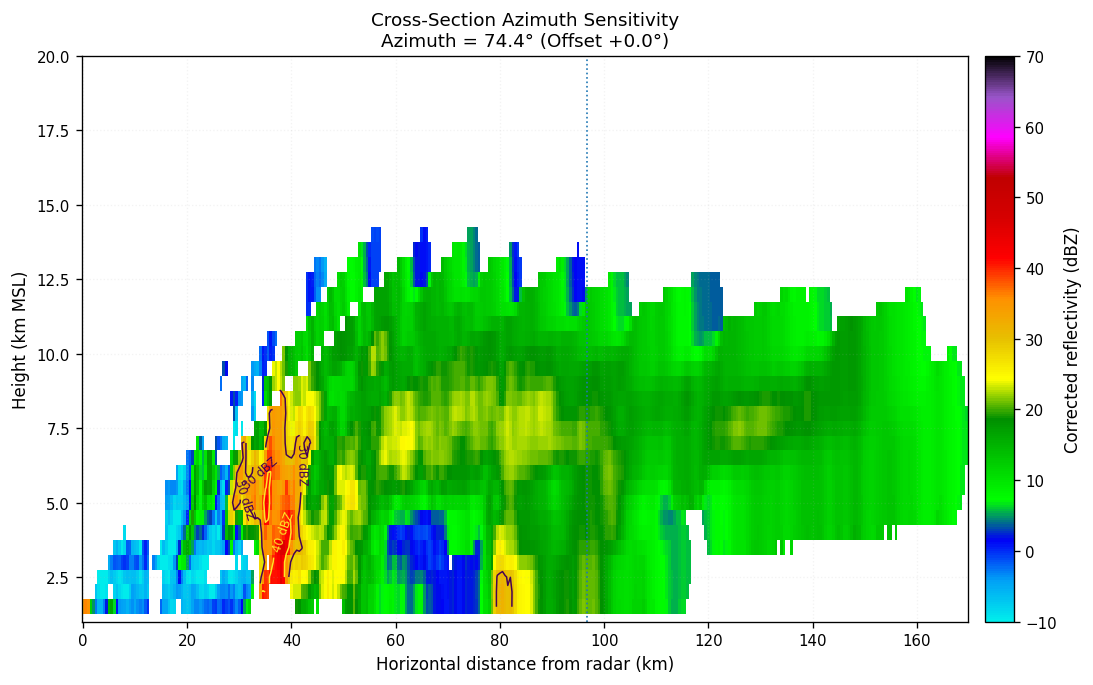

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_azimuth_sensitivity_78.4deg.png


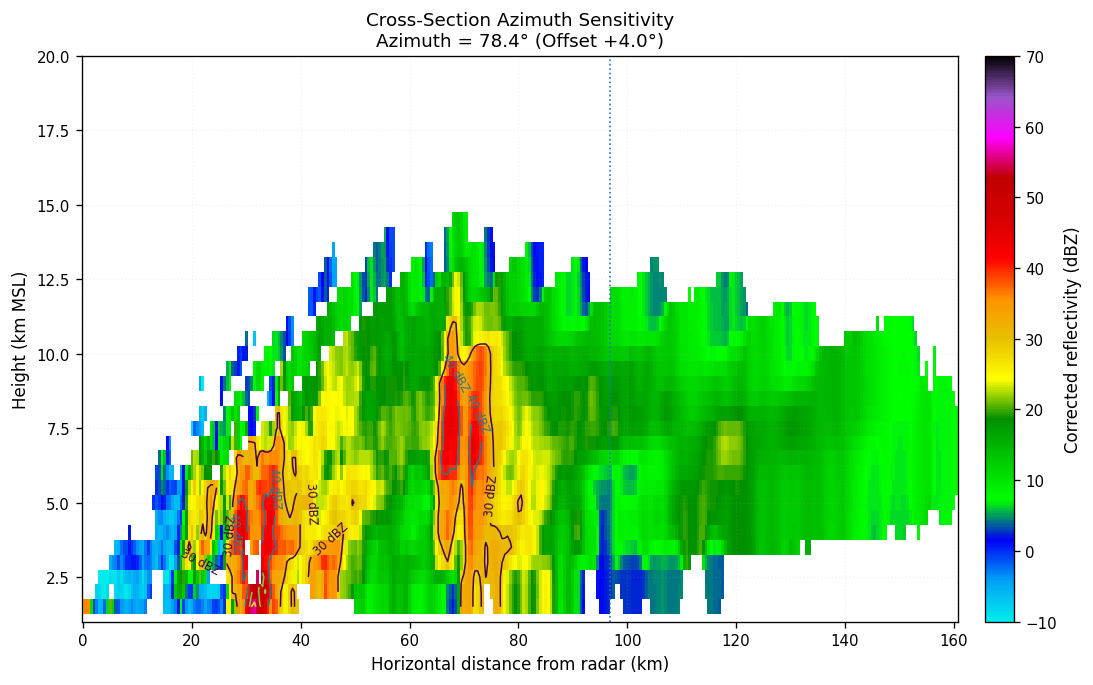

In [37]:
# CELL 37 — Export azimuth-sensitivity cross-section figures

for azimuth_deg, section_i in (
    AZIMUTH_SECTIONS.items()
):
    distance_i = (
        section_i[
            "distance_km"
        ]
    )

    z_i = (
        section_i[
            "z_km_MSL"
        ]
    )

    field_i = (
        section_i[
            "field"
        ]
    )

    fig = plt.figure(
        figsize=(
            9.0,
            5.6,
        )
    )

    ax = fig.add_subplot(
        111
    )

    mesh = ax.pcolormesh(
        distance_i,
        z_i,
        np.ma.masked_invalid(
            field_i
        ),
        shading="auto",
        cmap=(
            ZH_CMAP
        ),
        vmin=(
            ZH_VMIN
        ),
        vmax=(
            ZH_VMAX
        ),
        rasterized=True,
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        "Corrected reflectivity (dBZ)"
    )

    finite_values = (
        field_i[
            np.isfinite(
                field_i
            )
        ]
    )

    if finite_values.size:
        levels = [
            value
            for value in (
                REFLECTIVITY_CONTOURS_DBZ
            )
            if (
                np.nanmin(
                    finite_values
                )
                <= value
                <= np.nanmax(
                    finite_values
                )
            )
        ]

        if levels:
            contours = ax.contour(
                distance_i,
                z_i,
                field_i,
                levels=levels,
                linewidths=0.9,
            )

            ax.clabel(
                contours,
                fmt=lambda value: (
                    f"{value:.0f} dBZ"
                ),
                fontsize=7,
            )

    ax.axvline(
        CORE_REFERENCE_RANGE_KM,
        linestyle=":",
        linewidth=1.0,
    )

    for label, height_km in (
        THERMAL_LEVELS.items()
    ):
        ax.axhline(
            height_km,
            linestyle="--",
            linewidth=0.8,
            alpha=0.75,
        )

    ax.set_ylim(
        VERTICAL_DISPLAY_MIN_KM_MSL,
        VERTICAL_DISPLAY_MAX_KM_MSL,
    )

    ax.set_xlabel(
        "Horizontal distance from radar (km)"
    )

    ax.set_ylabel(
        "Height (km MSL)"
    )

    offset = (
        (
            (
                azimuth_deg
                - TARGET_AZIMUTH_DEG
                + 180.0
            )
            % 360.0
        )
        - 180.0
    )

    ax.set_title(
        (
            "Cross-Section Azimuth Sensitivity\n"
            f"Azimuth = {azimuth_deg:.1f}° "
            f"(Offset {offset:+.1f}°)"
        )
    )

    ax.grid(
        alpha=0.15,
        linestyle=":",
    )

    F = (
        FIGURE_DIR
        / (
            "06_azimuth_sensitivity_"
            f"{azimuth_deg:.1f}deg.png"
        )
    )

    save_figure(
        fig,
        F,
        product="azimuth sensitivity cross section",
        source_file=(
            SELECTED_FILENAME
        ),
        target_azimuth_deg=(
            azimuth_deg
        ),
        reference_azimuth_deg=(
            TARGET_AZIMUTH_DEG
        ),
        units="dBZ",
    )

    plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig12_azimuth_threshold_top_sensitivity.png


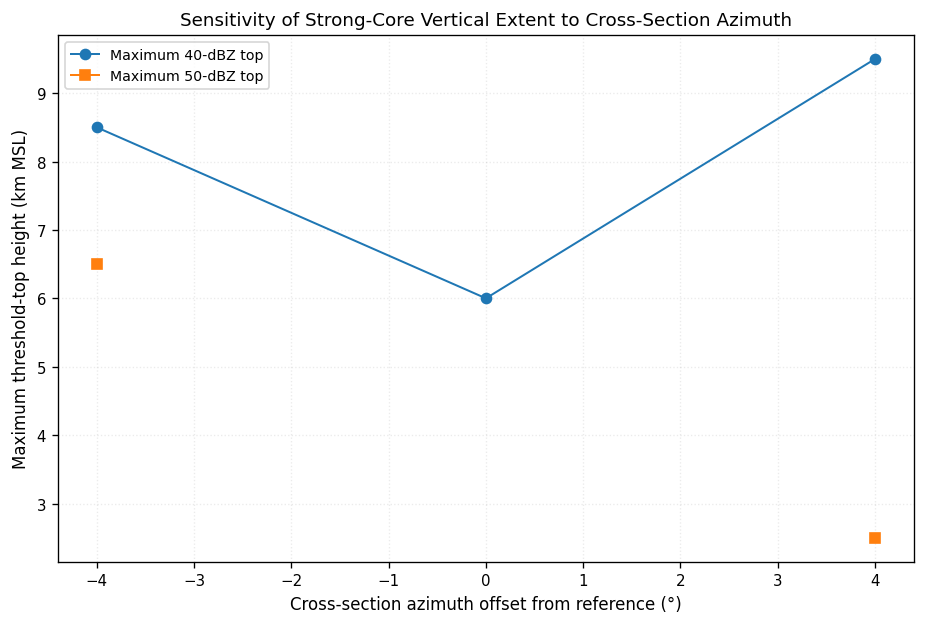

In [38]:
# CELL 38 — Azimuth-sensitivity metric figure

fig = plt.figure(
    figsize=(
        7.6,
        5.1,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    AZIMUTH_SENSITIVITY[
        "offset_from_reference_deg"
    ],
    AZIMUTH_SENSITIVITY[
        "maximum_40dBZ_top_km_MSL"
    ],
    marker="o",
    label="Maximum 40-dBZ top",
)

ax.plot(
    AZIMUTH_SENSITIVITY[
        "offset_from_reference_deg"
    ],
    AZIMUTH_SENSITIVITY[
        "maximum_50dBZ_top_km_MSL"
    ],
    marker="s",
    label="Maximum 50-dBZ top",
)

ax.set_xlabel(
    "Cross-section azimuth offset from reference (°)"
)

ax.set_ylabel(
    "Maximum threshold-top height (km MSL)"
)

ax.set_title(
    "Sensitivity of Strong-Core Vertical Extent to Cross-Section Azimuth"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "06_fig12_azimuth_threshold_top_sensitivity.png"
)

save_figure(
    fig,
    F,
    product="azimuth threshold-top sensitivity",
    source_file=(
        SELECTED_FILENAME
    ),
    reference_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    units="km MSL",
)

plt.show()

# 27. Native vs Cartesian comparison

Native pseudo-RHI และ Cartesian cross section ไม่ควรให้ค่าตรงกันทุกจุด เพราะ:

- native ray azimuth อาจคลาดจาก target azimuth เล็กน้อย
- Cartesian grid ผ่าน objective interpolation
- beam volume ถูกแทนด้วย grid cells
- high gradients อาจถูก smooth
- missing native gates อาจส่งผลต่อ interpolation

เราจะ sample Cartesian section ที่ range–height ของ native gates ที่อยู่ภายใน Cartesian section domain

ผลต่าง:

$$
\Delta Z_H
=
Z_{H,Cartesian}
-
Z_{H,Native}
$$

เป็น **representation difference**

ไม่ใช่ validation error

In [39]:
# CELL 39 — Build 2-D interpolator on Cartesian section

SECTION_INTERPOLATOR = (
    RegularGridInterpolator(
        (
            SECTION_Z_KM,
            SECTION_DISTANCE_KM,
        ),
        SECTION_ZH,
        bounds_error=False,
        fill_value=np.nan,
    )
)

comparison_native = (
    NATIVE_PSEUDO_RHI_TABLE.loc[
        NATIVE_PSEUDO_RHI_TABLE[
            "corrected_ZH_dBZ"
        ].notna()
        & (
            NATIVE_PSEUDO_RHI_TABLE[
                "azimuth_error_deg"
            ]
            <= AZIMUTH_TOLERANCE_DEG
        )
        & (
            NATIVE_PSEUDO_RHI_TABLE[
                "horizontal_range_km"
            ]
            >= SECTION_DISTANCE_KM.min()
        )
        & (
            NATIVE_PSEUDO_RHI_TABLE[
                "horizontal_range_km"
            ]
            <= SECTION_DISTANCE_KM.max()
        )
        & (
            NATIVE_PSEUDO_RHI_TABLE[
                "height_km_MSL"
            ]
            >= SECTION_Z_KM.min()
        )
        & (
            NATIVE_PSEUDO_RHI_TABLE[
                "height_km_MSL"
            ]
            <= SECTION_Z_KM.max()
        )
    ]
    .copy()
)

comparison_points = np.column_stack(
    [
        comparison_native[
            "height_km_MSL"
        ].to_numpy(
            dtype=float
        ),
        comparison_native[
            "horizontal_range_km"
        ].to_numpy(
            dtype=float
        ),
    ]
)

comparison_native[
    "cartesian_ZH_dBZ"
] = (
    SECTION_INTERPOLATOR(
        comparison_points
    )
)

comparison_native[
    "cartesian_minus_native_dB"
] = (
    comparison_native[
        "cartesian_ZH_dBZ"
    ]
    - comparison_native[
        "corrected_ZH_dBZ"
    ]
)

NATIVE_CARTESIAN_COMPARISON = (
    comparison_native.loc[
        comparison_native[
            "cartesian_ZH_dBZ"
        ].notna()
    ]
    .copy()
)

display(
    NATIVE_CARTESIAN_COMPARISON.head()
)

NATIVE_CARTESIAN_COMPARISON_CSV = (
    OUTPUT_CSV_DIR
    / "06_native_vs_cartesian_cross_section.csv"
)

NATIVE_CARTESIAN_COMPARISON.to_csv(
    NATIVE_CARTESIAN_COMPARISON_CSV,
    index=False,
)

,sweep,fixed_angle_deg,selected_azimuth_deg,azimuth_error_deg,gate_index,horizontal_range_km,height_km_MSL,corrected_ZH_dBZ,cartesian_ZH_dBZ,cartesian_minus_native_dB
62,0,0.5,74.015625,0.358849,62,31.247673,1.502,5.5,6.133022,0.633022
63,0,0.5,74.015625,0.358849,63,31.747610,1.509,8.0,8.722435,0.722435
82,0,0.5,74.015625,0.358849,82,41.246360,1.633,20.5,19.765517,-0.734483
83,0,0.5,74.015625,0.358849,83,41.746282,1.640,16.5,18.431638,1.931638
84,0,0.5,74.015625,0.358849,84,42.246212,1.647,15.0,17.159475,2.159475


In [40]:
# CELL 40 — Native-vs-Cartesian summary

comparison_diff = (
    NATIVE_CARTESIAN_COMPARISON[
        "cartesian_minus_native_dB"
    ].to_numpy(
        dtype=float
    )
)

NATIVE_CARTESIAN_SUMMARY = pd.DataFrame({
    "metric": [
        "common_points",
        "mean_cartesian_minus_native_dB",
        "median_cartesian_minus_native_dB",
        "P05_difference_dB",
        "P95_difference_dB",
        "RMSE_difference_dB",
    ],
    "value": [
        len(
            comparison_diff
        ),
        (
            float(
                np.nanmean(
                    comparison_diff
                )
            )
            if len(
                comparison_diff
            )
            else np.nan
        ),
        (
            float(
                np.nanmedian(
                    comparison_diff
                )
            )
            if len(
                comparison_diff
            )
            else np.nan
        ),
        (
            float(
                np.nanpercentile(
                    comparison_diff,
                    5,
                )
            )
            if len(
                comparison_diff
            )
            else np.nan
        ),
        (
            float(
                np.nanpercentile(
                    comparison_diff,
                    95,
                )
            )
            if len(
                comparison_diff
            )
            else np.nan
        ),
        (
            float(
                np.sqrt(
                    np.nanmean(
                        comparison_diff**2
                    )
                )
            )
            if len(
                comparison_diff
            )
            else np.nan
        ),
    ],
})

display(
    NATIVE_CARTESIAN_SUMMARY
)

NATIVE_CARTESIAN_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "06_native_vs_cartesian_summary.csv"
)

NATIVE_CARTESIAN_SUMMARY.to_csv(
    NATIVE_CARTESIAN_SUMMARY_CSV,
    index=False,
)

,metric,value
0,common_points,1932.000000
1,mean_cartesian_minus_native_dB,-0.060343
2,median_cartesian_minus_native_dB,-0.096127
3,P05_difference_dB,-3.447503
4,P95_difference_dB,3.650504
5,RMSE_difference_dB,2.424339


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/06/06_fig13_native_vs_cartesian_scatter.png


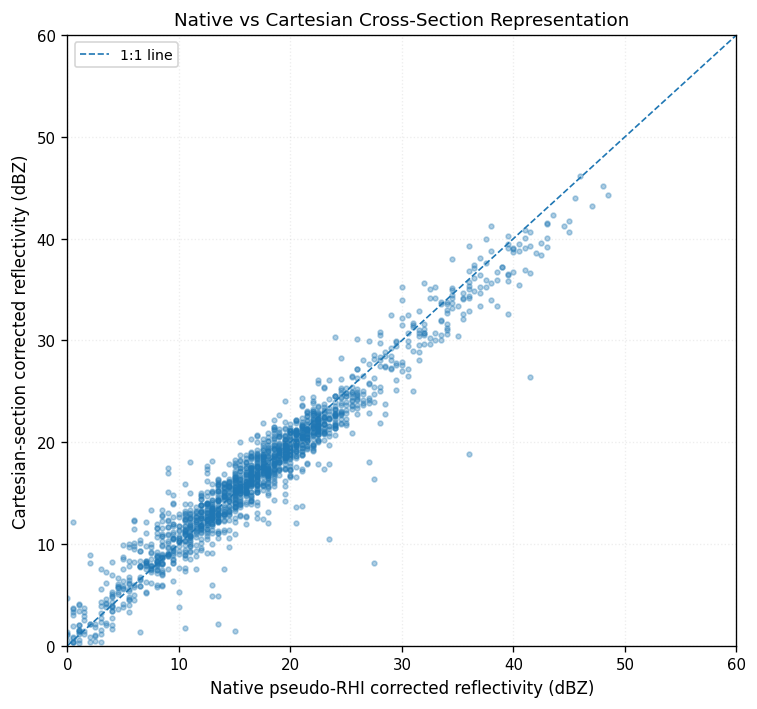

In [41]:
# CELL 41 — Native-vs-Cartesian scatter figure

comparison_plot = (
    NATIVE_CARTESIAN_COMPARISON.loc[
        (
            NATIVE_CARTESIAN_COMPARISON[
                "corrected_ZH_dBZ"
            ]
            >= 0.0
        )
        & (
            NATIVE_CARTESIAN_COMPARISON[
                "cartesian_ZH_dBZ"
            ]
            >= 0.0
        )
    ]
)

fig = plt.figure(
    figsize=(
        6.2,
        5.8,
    )
)

ax = fig.add_subplot(
    111
)

ax.scatter(
    comparison_plot[
        "corrected_ZH_dBZ"
    ],
    comparison_plot[
        "cartesian_ZH_dBZ"
    ],
    s=8,
    alpha=0.35,
    rasterized=True,
)

line_min = 0.0

line_max = max(
    60.0,
    float(
        np.nanmax(
            comparison_plot[
                [
                    "corrected_ZH_dBZ",
                    "cartesian_ZH_dBZ",
                ]
            ].to_numpy()
        )
    )
    if not comparison_plot.empty
    else 60.0,
)

ax.plot(
    [
        line_min,
        line_max,
    ],
    [
        line_min,
        line_max,
    ],
    linestyle="--",
    linewidth=1.0,
    label="1:1 line",
)

ax.set_xlim(
    line_min,
    line_max,
)

ax.set_ylim(
    line_min,
    line_max,
)

ax.set_xlabel(
    "Native pseudo-RHI corrected reflectivity (dBZ)"
)

ax.set_ylabel(
    "Cartesian-section corrected reflectivity (dBZ)"
)

ax.set_title(
    "Native vs Cartesian Cross-Section Representation"
)

ax.grid(
    alpha=0.22,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "06_fig13_native_vs_cartesian_scatter.png"
)

save_figure(
    fig,
    F,
    product="native versus Cartesian section comparison",
    source_file=(
        SELECTED_FILENAME
    ),
    target_azimuth_deg=(
        TARGET_AZIMUTH_DEG
    ),
    processing=(
        "Cartesian section sampled at native selected-ray range-height locations."
    ),
    units="dBZ",
)

plt.show()

# 28. สรุป vertical-structure metrics ของ selected cross section

Notebook นี้จะสร้าง summary หนึ่งแถวสำหรับ peak representative volume โดยรวม:

- maximum ZH
- height of maximum ZH
- distance of maximum ZH
- maximum 20/30/40/50-dBZ threshold-top height
- maximum 20-dBZ echo depth
- azimuth
- core reference range
- native azimuth sampling error
- thermal-level availability

ตารางนี้จะเป็น bridge ไป Notebook 07

In [42]:
# CELL 42 — Integrated vertical-structure summary

vertical_summary = {
    "event_id": (
        ACTIVE_EVENT.get(
            "event_id"
        )
    ),
    "source_file": (
        SELECTED_FILENAME
    ),
    "time_UTC": str(
        utc_time
    ),
    "target_azimuth_deg": (
        TARGET_AZIMUTH_DEG
    ),
    "dominant_sector": (
        DOMINANT_SECTOR
    ),
    "core_reference_range_km": (
        CORE_REFERENCE_RANGE_KM
    ),
    "maximum_ZH_in_section_dBZ": (
        SECTION_MAX_ZH_DBZ
    ),
    "height_of_maximum_ZH_km_MSL": (
        SECTION_MAX_ZH_HEIGHT_KM_MSL
    ),
    "distance_of_maximum_ZH_km": (
        SECTION_MAX_ZH_DISTANCE_KM
    ),
    "maximum_20dBZ_echo_depth_km": (
        float(
            np.nanmax(
                ECHO_DEPTH20_KM
            )
        )
        if np.isfinite(
            ECHO_DEPTH20_KM
        ).any()
        else np.nan
    ),
    "thermal_levels_available": (
        THERMAL_LEVELS_AVAILABLE
    ),
}

for threshold in (
    THRESHOLD_TOPS_DBZ
):
    top_values = (
        THRESHOLD_PRODUCTS[
            threshold
        ][
            "top_km_MSL"
        ]
    )

    vertical_summary[
        f"maximum_{int(threshold)}dBZ_top_km_MSL"
    ] = (
        float(
            np.nanmax(
                top_values
            )
        )
        if np.isfinite(
            top_values
        ).any()
        else np.nan
    )


VERTICAL_STRUCTURE_SUMMARY = pd.DataFrame(
    [
        vertical_summary
    ]
)

display(
    VERTICAL_STRUCTURE_SUMMARY
)

VERTICAL_STRUCTURE_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "06_vertical_structure_summary.csv"
)

VERTICAL_STRUCTURE_SUMMARY.to_csv(
    VERTICAL_STRUCTURE_SUMMARY_CSV,
    index=False,
)

,event_id,source_file,time_UTC,target_azimuth_deg,dominant_sector,core_reference_range_km,maximum_ZH_in_section_dBZ,height_of_maximum_ZH_km_MSL,distance_of_maximum_ZH_km,maximum_20dBZ_echo_depth_km,thermal_levels_available,maximum_20dBZ_top_km_MSL,maximum_30dBZ_top_km_MSL,maximum_40dBZ_top_km_MSL,maximum_50dBZ_top_km_MSL
0,20230318_observed_hail_1106_1200,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,74.374474,ENE,96.76895,46.394373,3.5,38.0,8.0,False,10.5,8.5,6.0,NaN


# 29. Optional interpretation relative to environmental thermal levels

หากมี thermal-level file Notebook จะคำนวณระยะในแนวดิ่งระหว่าง strong reflectivity top กับ:

```text
0°C
−10°C
−20°C
−30°C
```

ตัวอย่างแนวคิด:

$$
D_{40,-20}
=
ET_{40}
-
H_{-20^\circ C}
$$

หากค่าบวก หมายถึง 40-dBZ echo extends above −20°C level

แต่ยังไม่ใช่ hail confirmation

หากไม่มี environmental data ส่วนนี้จะรายงานว่า unavailable และไม่สร้างค่าจำลองขึ้นมา

In [43]:
# CELL 43 — Optional thermal-relative metrics

thermal_relative_rows = []

if THERMAL_LEVELS_AVAILABLE:

    for threshold in [
        40.0,
        50.0,
    ]:
        top_values = (
            THRESHOLD_PRODUCTS[
                threshold
            ][
                "top_km_MSL"
            ]
        )

        maximum_top = (
            float(
                np.nanmax(
                    top_values
                )
            )
            if np.isfinite(
                top_values
            ).any()
            else np.nan
        )

        for label, thermal_height in (
            THERMAL_LEVELS.items()
        ):
            thermal_relative_rows.append({
                "threshold_dBZ": (
                    threshold
                ),
                "thermal_level": (
                    label
                ),
                "thermal_height_km_MSL": (
                    thermal_height
                ),
                "maximum_threshold_top_km_MSL": (
                    maximum_top
                ),
                "top_minus_thermal_level_km": (
                    maximum_top
                    - thermal_height
                    if np.isfinite(
                        maximum_top
                    )
                    else np.nan
                ),
            })

else:
    thermal_relative_rows.append({
        "threshold_dBZ": np.nan,
        "thermal_level": (
            "not available"
        ),
        "thermal_height_km_MSL": np.nan,
        "maximum_threshold_top_km_MSL": np.nan,
        "top_minus_thermal_level_km": np.nan,
    })


THERMAL_RELATIVE_METRICS = pd.DataFrame(
    thermal_relative_rows
)

display(
    THERMAL_RELATIVE_METRICS
)

THERMAL_RELATIVE_CSV = (
    OUTPUT_CSV_DIR
    / "06_thermal_relative_vertical_metrics.csv"
)

THERMAL_RELATIVE_METRICS.to_csv(
    THERMAL_RELATIVE_CSV,
    index=False,
)

,threshold_dBZ,thermal_level,thermal_height_km_MSL,maximum_threshold_top_km_MSL,top_minus_thermal_level_km
0,NaN,not available,NaN,NaN,NaN


# 30. การตีความ hail-producing storm อย่างระมัดระวัง

จาก Notebook 06 เราสามารถอธิบายได้ว่า:

- intense reflectivity core อยู่ที่ระยะและความสูงใด
- 40/50-dBZ core ขยายสูงเพียงใดใน selected section
- vertical structure เปลี่ยนหรือไม่เมื่อเปลี่ยน azimuth
- native sampling และ Cartesian representation ต่างกันเท่าใด
- strong core อยู่เหนือ environmental thermal levels หรือไม่ หากมีข้อมูลอุณหภูมิ

แต่ยังไม่ควรเขียนว่า:

```text
ET50 proves hail
60 dBZ proves surface hail
highest radar echo = cloud top
radar echo base = cloud base
Cartesian grid gives exact storm geometry
```

Observed hail เป็น **event-level independent information** ในกรณีศึกษานี้  
ไม่ได้ทำให้ทุก high-reflectivity pixel กลายเป็น hail-confirmed pixel

# 31. แนวทางเขียน Methods

Methods ของ vertical cross-section analysis ควรรายงานอย่างน้อย:

1. radar site / band
2. source radar volume และ UTC time
3. scan strategy / elevation angles
4. target azimuth และวิธีเลือก
5. azimuth tolerance
6. pseudo-RHI extraction method
7. Cartesian-grid source
8. horizontal / vertical grid spacing
9. vertical reference: ARL หรือ MSL
10. cross-section sampling spacing
11. reflectivity thresholds
12. top/base censoring treatment
13. environmental thermal-level source หากใช้
14. sensitivity ต่อ cross-section azimuth

ตัวอย่างข้อความ:

> The vertical structure of the peak observed-hail volume was examined using both native polar and Cartesian representations. A pseudo-RHI was extracted from the 14-elevation PPI volume along the storm-core azimuth identified in the preceding analysis using Py-ART's `cross_section_ppi` utility with a 1° azimuth tolerance. In parallel, corrected reflectivity from the 0.5-km storm-focused three-dimensional Cartesian grid was sampled along the same radar-centered azimuth at 0.5-km horizontal intervals. Cartesian heights were referenced to MSL. Reflectivity-core structure was summarized using the height of maximum reflectivity and threshold-top levels for 20, 30, 40 and 50 dBZ. Threshold tops reaching the upper grid boundary and echo bases reaching the lower boundary were flagged as censored. Cross-section sensitivity was additionally evaluated at ±4° from the reference azimuth.

ก่อนใช้จริงใน manuscript ให้ตรวจตัวเลขจาก metadata CSV ที่รันจริง

# 32. CORE — แบบฝึกหัดสำหรับปริญญาตรี

### แบบฝึกหัด 1 — PPI vs pseudo-RHI

อธิบายว่า:

```text
0.5° PPI
```

ต่างจาก:

```text
pseudo-RHI at 74°
```

อย่างไร

### แบบฝึกหัด 2 — Native beam sampling

ใช้ `06_native_sweep_cross_section_sampling.csv`

ตอบ:

- sweep ต่ำสุด sample ความสูงเท่าใดที่ core range?
- sweep ใดใกล้ 5 km MSL?
- sweep ใดใกล้ 10 km MSL?
- azimuth error สูงสุดเท่าใด?

### แบบฝึกหัด 3 — Maximum reflectivity

จาก `06_strongest_column_vertical_structure.csv`

หา:

- maximum ZH
- height of maximum ZH
- distance from radar

### แบบฝึกหัด 4 — Echo top ไม่ใช่ cloud top

อธิบายเหตุผลอย่างน้อย 3 ข้อว่าทำไม radar echo top จึงไม่เท่ากับ physical cloud top

# 33. ADVANCED / MSc — แบบฝึกหัด

### แบบฝึกหัด 5 — Threshold-top analysis

ใช้ `06_cross_section_threshold_top_summary.csv`

เปรียบเทียบ:

```text
20
30
40
50 dBZ
```

และอธิบายว่า threshold สูงขึ้นทำให้ vertical extent เปลี่ยนอย่างไร

### แบบฝึกหัด 6 — Censoring

หา columns ที่:

```text
top_censored = True
base_censored = True
```

อภิปรายว่าทำไม storm depth ใน columns เหล่านี้จึงต้องตีความระมัดระวัง

### แบบฝึกหัด 7 — Native vs Cartesian

ใช้ `06_native_vs_cartesian_summary.csv`

อภิปราย:

- bias-like mean difference
- median difference
- P05/P95
- RMSE-like representation difference

เหตุใดตัวเลขเหล่านี้จึงไม่ควรเรียกว่า validation error?

### แบบฝึกหัด 8 — Azimuth sensitivity

ใช้ `06_azimuth_sensitivity.csv`

เปรียบเทียบ cross section ที่:

```text
reference − 4°
reference
reference + 4°
```

ระบุว่าแนวใดให้:

- highest 40-dBZ top
- highest 50-dBZ top
- largest 50-dBZ vertical-plane area

# 34. RESEARCH — แบบฝึกหัดสำหรับต่อยอดงานตีพิมพ์

### แบบฝึกหัด 9 — Cross-section selection strategy

แทนที่จะใช้ median strong-echo azimuth จาก lowest sweep อย่างเดียว ลองเสนอวิธีเลือกแนวตัดจาก:

- 3-D maximum ZH
- 50-dBZ centroid
- storm motion vector
- tracked storm-object major axis

อภิปรายข้อดีและข้อเสีย

### แบบฝึกหัด 10 — Thermal structure

หากมี sounding/reanalysis ให้สร้าง:

```text
freezing level
−10°C
−20°C
−30°C
```

แล้ววิเคราะห์ว่า 40/50-dBZ core extends above แต่ละระดับกี่ km

### แบบฝึกหัด 11 — Publication figure

เลือก Cartesian vertical cross section แล้วเขียน caption ที่ระบุ:

- event
- radar
- UTC
- target azimuth
- grid spacing
- MSL reference
- reflectivity contours
- thermal-level source หากมี
- interpolation limitation

# 35. สิ่งที่ Notebook 06 ยังไม่ทำ

Notebook นี้ยังไม่สร้าง final:

- 2-D ET20 / ET30 / ET40 / ET50 maps
- full 3-D echo volume
- VIL
- VILD
- storm-object segmentation
- 10-volume severe-storm lifecycle
- MESH
- HSDA
- HDR

เหตุผลคือ Notebook 06 เน้น:

```text
understand vertical structure first
```

ก่อนเปลี่ยน structure เป็น automated severe-storm metrics ใน Notebook 07

# 36. Export processing metadata

In [44]:
# CELL 44 — Processing metadata

PROCESSING_METADATA = pd.DataFrame({
    "parameter": [
        "event_id",
        "event_type",
        "radar_site",
        "radar_band",
        "source_file",
        "time_UTC",
        "reflectivity_field",
        "n_native_sweeps",
        "target_azimuth_deg",
        "dominant_sector",
        "core_reference_range_km",
        "azimuth_tolerance_deg",
        "azimuth_sensitivity_deg",
        "pseudo_RHI_method",
        "pseudo_RHI_vertical_reference",
        "cartesian_grid_file",
        "cartesian_horizontal_spacing_km",
        "cartesian_vertical_spacing_km",
        "cartesian_vertical_reference",
        "cross_section_spacing_km",
        "threshold_tops_dBZ",
        "echo_base_threshold_dBZ",
        "top_base_censoring",
        "thermal_levels_available",
        "thermal_level_source",
        "native_cartesian_comparison_interpretation",
        "scientific_interpretation",
    ],
    "value": [
        ACTIVE_EVENT.get(
            "event_id"
        ),
        ACTIVE_EVENT.get(
            "event_type"
        ),
        "Omkoi",
        COURSE_CONFIG[
            "radar"
        ].get(
            "band"
        ),
        SELECTED_FILENAME,
        str(
            utc_time
        ),
        FIELD_Z,
        radar.nsweeps,
        TARGET_AZIMUTH_DEG,
        DOMINANT_SECTOR,
        CORE_REFERENCE_RANGE_KM,
        AZIMUTH_TOLERANCE_DEG,
        str(
            AZIMUTH_EXPERIMENT_DEG
        ),
        (
            "Py-ART cross_section_ppi from native PPI sweeps"
        ),
        (
            "height above radar in Py-ART pseudo-RHI display"
        ),
        str(
            STORM_GRID_NETCDF
        ),
        float(
            grid_config_lookup[
                "storm_grid_dx_km"
            ]
        ),
        float(
            grid_config_lookup[
                "storm_grid_dz_km"
            ]
        ),
        "MSL",
        SECTION_SPACING_KM,
        str(
            THRESHOLD_TOPS_DBZ
        ),
        ECHO_BASE_THRESHOLD_DBZ,
        (
            "Threshold top/base at upper/lower grid boundary flagged as censored."
        ),
        THERMAL_LEVELS_AVAILABLE,
        (
            str(
                THERMAL_LEVEL_SOURCE
            )
            if THERMAL_LEVEL_SOURCE is not None
            else "not available"
        ),
        (
            "Representation difference; not validation error."
        ),
        (
            "Observed-hail event vertical-structure characterization; "
            "high reflectivity is not pixel-level hail confirmation."
        ),
    ],
})

display(
    PROCESSING_METADATA
)

PROCESSING_METADATA_CSV = (
    OUTPUT_CSV_DIR
    / "06_processing_metadata.csv"
)

PROCESSING_METADATA.to_csv(
    PROCESSING_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    PROCESSING_METADATA_CSV,
)

,parameter,value
0,event_id,20230318_observed_hail_1106_1200
1,event_type,observed_hail
2,radar_site,Omkoi
3,radar_band,S
4,source_file,20230318111202.uf.gz
5,time_UTC,2023-03-18 11:12:02+00:00
6,reflectivity_field,corrected_reflectivity
7,n_native_sweeps,14
8,target_azimuth_deg,74.374474
9,dominant_sector,ENE


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/06_processing_metadata.csv


# 37. Export figure manifest

In [45]:
# CELL 45 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    FIGURE_RECORDS
)

FIGURE_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "06_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

print(
    "Saved:",
    FIGURE_MANIFEST_CSV,
)

,figure_name,figure_path,product,source_file,target_azimuth_deg,core_reference_range_km,units,dpi,sweep,field,processing,distance_km,reference_azimuth_deg
0,06_fig01_beam_sampling_at_core_range.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,beam sampling at core range,20230318111202.uf.gz,74.374474,96.76895,km MSL,300,NaN,NaN,NaN,NaN,NaN
1,06_fig02_reference_PPI_cross_section_line.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,PPI cross-section reference,20230318111202.uf.gz,74.374474,NaN,dBZ,300,0.0,corrected_reflectivity,NaN,NaN,NaN
2,06_fig03_native_pseudo_RHI.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,native pseudo-RHI,20230318111202.uf.gz,74.374474,NaN,dBZ,300,NaN,corrected_reflectivity,Py-ART cross_section_ppi using az_tol=1 degree.,NaN,NaN
3,06_fig04_native_gate_sampling.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,native pseudo-RHI gate sampling,20230318111202.uf.gz,74.374474,NaN,dBZ,300,NaN,corrected_reflectivity,NaN,NaN,NaN
4,06_fig05_cartesian_vertical_cross_section.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,Cartesian vertical cross section,20230318111202.uf.gz,74.374474,NaN,dBZ,300,NaN,corrected_reflectivity,0.5-km storm-focused 3-D Cartesian grid; radia...,NaN,NaN
5,06_fig06_height_of_max_reflectivity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,height of maximum reflectivity,20230318111202.uf.gz,74.374474,NaN,km MSL,300,NaN,NaN,NaN,NaN,NaN
6,06_fig07_cross_section_threshold_top_preview.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,cross-section threshold-top preview,20230318111202.uf.gz,74.374474,NaN,km MSL,300,NaN,NaN,Highest 0.5-km Cartesian grid level meeting ea...,NaN,NaN
7,06_fig08_strongest_column_vertical_profile.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,strongest-column vertical profile,20230318111202.uf.gz,74.374474,NaN,dBZ,300,NaN,NaN,NaN,38.0,NaN
8,06_azimuth_sensitivity_70.4deg.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,azimuth sensitivity cross section,20230318111202.uf.gz,70.374474,NaN,dBZ,300,NaN,NaN,NaN,NaN,74.374474
9,06_azimuth_sensitivity_74.4deg.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,azimuth sensitivity cross section,20230318111202.uf.gz,74.374474,NaN,dBZ,300,NaN,NaN,NaN,NaN,74.374474


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/06_figure_manifest.csv


# 38. Output inventory

In [46]:
# CELL 46 — Output inventory

EXPECTED_OUTPUTS = [
    SWEEP_SAMPLING_CSV,
    NATIVE_PSEUDO_RHI_CSV,
    CARTESIAN_SECTION_CSV,
    HEIGHT_MAX_CSV,
    THRESHOLD_TOP_CSV,
    THRESHOLD_TOP_SUMMARY_CSV,
    ECHO_DEPTH20_CSV,
    CORE_VERTICAL_SUMMARY_CSV,
    AZIMUTH_SENSITIVITY_CSV,
    NATIVE_CARTESIAN_COMPARISON_CSV,
    NATIVE_CARTESIAN_SUMMARY_CSV,
    VERTICAL_STRUCTURE_SUMMARY_CSV,
    THERMAL_RELATIVE_CSV,
    PROCESSING_METADATA_CSV,
    FIGURE_MANIFEST_CSV,
]

OUTPUT_INVENTORY = pd.DataFrame({
    "path": [
        str(
            path
        )
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
    "exists": [
        Path(
            path
        ).exists()
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
})

display(
    OUTPUT_INVENTORY
)

,path,exists
0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
1,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
3,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
5,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
7,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
8,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
9,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True


# 39. Final readiness check

In [47]:
# CELL 47 — Notebook 06 readiness

checks = []


def add_check(
    item,
    passed,
    note="",
):
    checks.append({
        "item": (
            item
        ),
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": (
            note
        ),
    })


add_check(
    "Notebook 03 readiness",
    bool(
        (
            readiness_03[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_check(
    "Active event is observed hail",
    ACTIVE_EVENT.get(
        "event_type"
    )
    == "observed_hail",
)

add_check(
    "Peak native radar volume readable",
    radar is not None,
)

add_check(
    "Corrected reflectivity available",
    FIELD_Z in radar.fields,
)

add_check(
    "Fourteen native elevation sweeps available",
    int(
        radar.nsweeps
    )
    == 14,
)

add_check(
    "All sweeps have a ray within azimuth tolerance",
    bool(
        (
            SWEEP_SAMPLING[
                "azimuth_error_deg"
            ]
            <= AZIMUTH_TOLERANCE_DEG
        ).all()
    ),
    (
        f"maximum azimuth error = "
        f"{SWEEP_SAMPLING['azimuth_error_deg'].max():.2f}°"
    ),
)

add_check(
    "Py-ART pseudo-RHI created",
    pseudo_rhi is not None,
)

add_check(
    "Full-domain 3-D grid readable",
    full_grid is not None,
)

add_check(
    "Storm-focused 3-D grid readable",
    storm_grid is not None,
)

add_check(
    "Main Cartesian cross section contains valid data",
    bool(
        np.isfinite(
            SECTION_ZH
        ).any()
    ),
)

add_check(
    "Cross-section threshold tops calculated",
    len(
        THRESHOLD_PRODUCTS
    )
    == len(
        THRESHOLD_TOPS_DBZ
    ),
)

add_check(
    "Strongest-column vertical profile available",
    bool(
        np.isfinite(
            CORE_VERTICAL_PROFILE
        ).any()
    ),
)

add_check(
    "Azimuth sensitivity completed",
    len(
        AZIMUTH_SENSITIVITY
    )
    == len(
        AZIMUTH_EXPERIMENT_DEG
    ),
)

add_check(
    "Native-vs-Cartesian comparison available",
    len(
        NATIVE_CARTESIAN_COMPARISON
    )
    > 0,
)

add_check(
    "Sweep sampling exported",
    SWEEP_SAMPLING_CSV.exists(),
)

add_check(
    "Native pseudo-RHI table exported",
    NATIVE_PSEUDO_RHI_CSV.exists(),
)

add_check(
    "Cartesian section exported",
    CARTESIAN_SECTION_CSV.exists(),
)

add_check(
    "Threshold-top summary exported",
    THRESHOLD_TOP_SUMMARY_CSV.exists(),
)

add_check(
    "Azimuth sensitivity exported",
    AZIMUTH_SENSITIVITY_CSV.exists(),
)

add_check(
    "Vertical-structure summary exported",
    VERTICAL_STRUCTURE_SUMMARY_CSV.exists(),
)

add_check(
    "Processing metadata exported",
    PROCESSING_METADATA_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_CSV.exists(),
)


READINESS_06 = pd.DataFrame(
    checks
)

display(
    READINESS_06
)

NOTEBOOK_06_READY = bool(
    (
        READINESS_06[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_06_CSV = (
    OUTPUT_CSV_DIR
    / "06_readiness_check.csv"
)

READINESS_06.to_csv(
    READINESS_06_CSV,
    index=False,
)

print()

print(
    (
        "NOTEBOOK 06 READY FOR "
        "ECHO-TOP, VIL, VILD AND SEVERE-CORE METRICS"
    )
    if NOTEBOOK_06_READY
    else "NOTEBOOK 06 REQUIRES REVIEW"
)

,item,status,note
0,Notebook 03 readiness,PASS,
1,Active event is observed hail,PASS,
2,Peak native radar volume readable,PASS,
3,Corrected reflectivity available,PASS,
4,Fourteen native elevation sweeps available,PASS,
5,All sweeps have a ray within azimuth tolerance,PASS,maximum azimuth error = 0.52°
6,Py-ART pseudo-RHI created,PASS,
7,Full-domain 3-D grid readable,PASS,
8,Storm-focused 3-D grid readable,PASS,
9,Main Cartesian cross section contains valid data,PASS,



NOTEBOOK 06 READY FOR ECHO-TOP, VIL, VILD AND SEVERE-CORE METRICS


# ข้อความสำคัญที่ต้องจำ

1. **PPI ไม่ใช่ horizontal constant-altitude surface**
2. **Pseudo-RHI ไม่ใช่ true RHI scan**
3. Pseudo-RHI สร้างจาก rays ของหลาย PPI sweeps
4. ต้องตรวจ azimuth mismatch ของ ray ที่เลือก
5. Native polar sampling และ Cartesian grid เป็นคนละ representation
6. Cartesian cross section ผ่าน interpolation
7. Grid spacing ไม่ใช่ observational resolution
8. Native pseudo-RHI display ของ Py-ART ใช้ความสูงเหนือ radar เป็นหลัก
9. Cartesian grid ของหลักสูตรนี้ใช้ความสูงอ้างอิง MSL
10. ARL และ MSL ต้องไม่ถูกปะปน
11. Height of maximum ZH ไม่ใช่ echo top
12. Threshold top ขึ้นกับ reflectivity threshold
13. ET20, ET40 และ ET50 มีความหมายต่างกัน
14. ET50 ไม่ใช่ hail confirmation
15. Radar echo top ไม่ใช่ cloud top
16. Radar echo base ไม่ใช่ thermodynamic cloud base
17. Grid ceiling สามารถทำให้ threshold top ถูก censored
18. Grid floor สามารถทำให้ echo base ถูก censored
19. Cross-section azimuth มีผลต่อ vertical interpretation
20. 40/50-dBZ core ที่สูงมากเป็น severe-storm diagnostic แต่ไม่ใช่หลักฐาน hail เพียงตัวเดียว
21. Environmental thermal levels ต้องมาจาก sounding/reanalysis/observation ไม่ควร hard-code
22. Native-vs-Cartesian difference เป็น representation difference ไม่ใช่ validation error
23. Observed hail เป็น event-level information ไม่ใช่ pixel-level hail truth
24. Notebook 07 จะเปลี่ยน vertical structure เป็น automated ET/VIL/VILD severe-storm metrics

# Expected outputs

```text
event-specific 03_output/csv/
├── 06_native_sweep_cross_section_sampling.csv
├── 06_native_pseudo_RHI_gate_table.csv
├── 06_cartesian_vertical_cross_section.csv
├── 06_height_of_max_reflectivity_along_section.csv
├── 06_cross_section_threshold_top_base.csv
├── 06_cross_section_threshold_top_summary.csv
├── 06_cross_section_echo_depth_20dBZ.csv
├── 06_strongest_column_vertical_structure.csv
├── 06_azimuth_sensitivity.csv
├── 06_native_vs_cartesian_cross_section.csv
├── 06_native_vs_cartesian_summary.csv
├── 06_vertical_structure_summary.csv
├── 06_thermal_relative_vertical_metrics.csv
├── 06_processing_metadata.csv
├── 06_figure_manifest.csv
└── 06_readiness_check.csv
```

ตัวอย่าง figures:

```text
event-specific 04_figures/06/
├── beam sampling at core range
├── reference PPI + cross-section line
├── native Py-ART pseudo-RHI
├── native gate sampling
├── Cartesian vertical cross section
├── height of maximum reflectivity
├── threshold-top preview
├── strongest-column vertical profile
├── azimuth sensitivity cross sections
├── azimuth threshold-top sensitivity
└── native-vs-Cartesian comparison
```

เมื่อ cell สุดท้ายแสดง:

```text
NOTEBOOK 06 READY FOR ECHO-TOP, VIL, VILD AND SEVERE-CORE METRICS
```

จึงเข้าสู่:

**Notebook 07 — Echo Tops, VIL, VILD and Severe-Storm Core Metrics**

# Technical references

หัวข้อที่ควรอ่านต่อ:

- Py-ART `cross_section_ppi`
- Py-ART `RadarDisplay` / pseudo-RHI plotting
- Py-ART Cartesian `Grid`
- radar beam geometry
- threshold-based echo-top concepts
- severe-convective vertical reflectivity structure

แนวคิดสำคัญสำหรับงานวิจัยคือ:

```text
Native observation
→ sampling geometry
→ interpolation
→ vertical diagnostic
→ physical interpretation
```

ไม่ควรข้ามจาก:

```text
colorful cross-section figure
```

ไปเป็น:

```text
severe-weather conclusion
```

โดยไม่ตรวจ sampling support และ methodological assumptions